# Notebook 44 — Class-Conditional Structural Audit & Rate-Feature Sanity
## Purpose

Notebook 41 established four key findings:

1. **No implementation-level leakage** — the clean pipeline computes every feature identically across VNAT, ISCX, and USBVPN.
2. **Severe structural dataset shift** — domain-classifier AUC ≈ 1.0 using only header-derived features.
3. **LODO collapse** — leave-one-dataset-out transfer drops to near-random (min AUC ≈ 0.42–0.45).
4. **Structural domain fingerprinting** — manifold projections and divergence metrics confirm that the feature space encodes dataset identity.

**Notebook 44** now investigates the *remaining unresolved technical questions* that Notebook 41 left open:

| # | Question | Section |
|---|----------|---------|
| Q1 | Is the structural shift concentrated in **VPN traffic**, **benign traffic**, or **both**? | §2 |
| Q2 | Are **rate features** (packet_rate, byte_rate) introducing hidden instability or unit inconsistency? | §3 |
| Q3 | Do any features **reverse their VPN-vs-nonVPN effect direction** across datasets (sign inversion)? | §4 |
| Q4 | Does the domain-classifier AUC ≈ 1.0 claim survive **capture-safe** evaluation? | §5 |
| Q5 | Are manifold visualizations presented with sufficient **methodological caution** for publication? | §6 |

### Design principles
- All outputs are saved to `artifacts/thesis_class_conditional_audit_notebook/` — **no prior artifacts are overwritten**.
- All conclusions are conservative and publication-safe.
- Missing artifacts or assumptions are flagged explicitly.

---
## Section 0 — Environment Setup & Imports

In [1]:
# ── Environment & Imports ───────────────────────────────────────────────
import sys, os, json, warnings, pathlib, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")           # safe for headless runs; switch to inline in JupyterLab
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance, mannwhitneyu, spearmanr, pearsonr
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, confusion_matrix,
    classification_report
)
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
import xgboost as xgb

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", font_scale=1.15)

# Try UMAP — optional
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("WARNING: umap-learn not installed — UMAP projections will be skipped.")

# Try t-SNE from sklearn
from sklearn.manifold import TSNE
HAS_TSNE = True

# Project root
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Artifact paths
CLEAN_DIR = PROJECT_ROOT / "artifacts" / "clean_pipeline"
OUT_DIR   = PROJECT_ROOT / "artifacts" / "thesis_class_conditional_audit_notebook"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Clean dir    : {CLEAN_DIR}")
print(f"Output dir   : {OUT_DIR}")
print(f"UMAP avail   : {HAS_UMAP}")

Project root : C:\Users\scoti\PycharmProjects\ai-vpn-firewall
Clean dir    : C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\clean_pipeline
Output dir   : C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook
UMAP avail   : True


In [2]:
# ── Helper: thesis-quality figure saver ─────────────────────────────────
def save_fig(fig, name, dpi=200):
    """Save figure to output dir and display inline."""
    path = OUT_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"Saved: {path}")
    plt.show()
    plt.close(fig)

def save_csv(df, name):
    path = OUT_DIR / name
    df.to_csv(path, index=True)
    print(f"Saved: {path}")

def save_json(obj, name):
    path = OUT_DIR / name
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)
    print(f"Saved: {path}")

---
## Section 1 — Load Frozen Data & Verify Representation Consistency

The clean pipeline extracts features into the `direction_invariant_augmented` family (25 features).  
The frozen final model uses the `safe_core_plus_temporal` / `full_no_dir` subset (21 features).  
The extra 4 direction-invariant augmented features exist in storage but are **excluded** from the frozen final model.

This section explicitly verifies and documents that distinction.

In [3]:
# ── Load clean-pipeline features ────────────────────────────────────────
features_path = CLEAN_DIR / "features.parquet"
assert features_path.exists(), f"Missing {features_path}"
df_all = pd.read_parquet(features_path)
print(f"Loaded {len(df_all)} flows × {df_all.shape[1]} columns")
print(f"Datasets : {sorted(df_all['dataset'].unique())}")
print(f"Labels   : {sorted(df_all['label'].unique())}")

Loaded 72612 flows × 32 columns
Datasets : ['iscx', 'usbvpn', 'vnat']
Labels   : [np.int64(0), np.int64(1)]


In [4]:
# ── Feature family definitions from source ──────────────────────────────
# Importing directly from the project source to be authoritative.
sys.path.insert(0, str(PROJECT_ROOT))
from src.clean_pipeline.feature_families import (
    SAFE_CORE_PLUS_TEMPORAL,
    DIRECTION_INVARIANT_AUGMENTED,
    FAMILY_REGISTRY,
    get_family,
)

extracted_family_name = "direction_invariant_augmented"
frozen_family_name    = "safe_core_plus_temporal"   # = full_no_dir (21 features)

extracted_features = list(get_family(extracted_family_name))
frozen_features    = list(get_family(frozen_family_name))
excluded_features  = sorted(set(extracted_features) - set(frozen_features))

print(f"Extracted family : {extracted_family_name}  ({len(extracted_features)} features)")
print(f"Frozen family    : {frozen_family_name}     ({len(frozen_features)} features)")
print(f"Excluded (present but not used) : {excluded_features}  ({len(excluded_features)} features)")

# Verify all frozen features are present in the dataframe
meta_cols = ["flow_id", "capture_id", "dataset", "label", "source_file", "app", "split"]
feat_cols_in_df = [c for c in df_all.columns if c not in meta_cols]
missing_frozen = [f for f in frozen_features if f not in feat_cols_in_df]
missing_extracted = [f for f in extracted_features if f not in feat_cols_in_df]
print(f"Missing frozen features in df  : {missing_frozen}")
print(f"Missing extracted features in df: {missing_extracted}")
assert len(missing_frozen) == 0, "Frozen features missing from data!"

Extracted family : direction_invariant_augmented  (25 features)
Frozen family    : safe_core_plus_temporal     (21 features)
Excluded (present but not used) : ['dir_bytes_ratio_minmax', 'dir_mean_pkt_max', 'dir_mean_pkt_min', 'dir_pkt_ratio_minmax']  (4 features)
Missing frozen features in df  : []
Missing extracted features in df: []


In [5]:
# ── Feature family consistency table ────────────────────────────────────
rows = []
for name, feats in FAMILY_REGISTRY.items():
    rows.append({
        "family": name,
        "n_features": len(feats),
        "is_frozen_final": name == frozen_family_name,
        "is_extracted": name == extracted_family_name,
    })
family_table = pd.DataFrame(rows)
display(family_table)

# Detailed feature-level table
feat_rows = []
for f in extracted_features:
    feat_rows.append({
        "feature": f,
        "in_extracted_25": True,
        "in_frozen_21": f in frozen_features,
        "excluded_but_present": f in excluded_features,
    })
feat_detail = pd.DataFrame(feat_rows)
display(feat_detail)
save_csv(feat_detail, "feature_family_consistency_table.csv")

,family,n_features,is_frozen_final,is_extracted
0,safe_core_10,10,False,False
1,safe_core_plus_duration,15,False,False
2,safe_core_plus_temporal,21,True,False
3,direction_invariant_augmented,25,False,True
4,direction_augmented,33,False,False


,feature,in_extracted_25,in_frozen_21,excluded_but_present
0,total_packets,True,True,False
1,total_bytes,True,True,False
2,mean_pkt_len,True,True,False
3,std_pkt_len,True,True,False
4,median_pkt_len,True,True,False
5,p25_pkt_len,True,True,False
6,p75_pkt_len,True,True,False
7,iat_mean,True,True,False
8,iat_std,True,True,False
9,iat_median,True,True,False


Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\feature_family_consistency_table.csv


### Interpretation

- The clean pipeline **extracts 25 features** (direction_invariant_augmented).
- The frozen final model **uses 21 features** (safe_core_plus_temporal = full_no_dir).
- The **4 excluded features** (`dir_pkt_ratio_minmax`, `dir_bytes_ratio_minmax`, `dir_mean_pkt_max`, `dir_mean_pkt_min`) are direction-invariant augmentations that are present in storage but excluded from the frozen final model because the best LODO results came from the 21-feature `full_no_dir` family.
- This is **not an error** — it is a deliberate design decision documented in the family search (eval_v3).

---
## Section 2 — Class-Conditional Dataset Structure Audit

**This is the most important section of the notebook.**

We repeat the structural analysis separately for:
- **VPN-only** flows (label = 1)
- **nonVPN-only** flows (label = 0)

This determines whether the cross-dataset failure is driven by benign traffic mismatch, VPN traffic mismatch, or both.

### Sub-analyses:
- A. Distribution distance metrics (Jensen–Shannon, Wasserstein)
- B. Class-conditional domain classification
- C. Manifold projections per class
- D. Correlation structure shift per class
- E. Class-conditional verdict

In [6]:
# ── Prepare class-conditional subsets ───────────────────────────────────
FEAT_COLS = list(frozen_features)   # 21 frozen features
DATASETS  = sorted(df_all["dataset"].unique())

df_vpn    = df_all[df_all["label"] == 1].copy()
df_nonvpn = df_all[df_all["label"] == 0].copy()

print(f"VPN flows    : {len(df_vpn):,}")
print(f"nonVPN flows : {len(df_nonvpn):,}")
print()
print("VPN per dataset:")
print(df_vpn["dataset"].value_counts())
print()
print("nonVPN per dataset:")
print(df_nonvpn["dataset"].value_counts())

VPN flows    : 11,773
nonVPN flows : 60,839

VPN per dataset:
dataset
usbvpn    8456
iscx      2943
vnat       374
Name: count, dtype: int64

nonVPN per dataset:
dataset
usbvpn    44248
iscx       8858
vnat       7733
Name: count, dtype: int64


### 2A — Per-Feature Distribution Distances (Class-Conditional)

For each class subset (VPN-only / nonVPN-only) and each pair of datasets, we compute:
- **Jensen–Shannon divergence** (symmetric, bounded [0, ln2])
- **Wasserstein distance** (Earth Mover's Distance, scale-dependent)

Both are computed per feature, then averaged.

In [7]:
# ── Distribution distance computation ───────────────────────────────────
from itertools import combinations

def compute_pairwise_distances(df_subset, feat_cols, n_bins=100):
    """
    Compute per-feature JSD and Wasserstein for each dataset pair.
    Returns a DataFrame: (feature, pair) → (jsd, wasserstein)
    """
    datasets = sorted(df_subset["dataset"].unique())
    rows = []
    for f in feat_cols:
        vals_by_ds = {}
        for ds in datasets:
            v = df_subset.loc[df_subset["dataset"] == ds, f].dropna().values
            vals_by_ds[ds] = v

        for ds_a, ds_b in combinations(datasets, 2):
            va, vb = vals_by_ds[ds_a], vals_by_ds[ds_b]
            if len(va) < 10 or len(vb) < 10:
                rows.append({"feature": f, "pair": f"{ds_a}_vs_{ds_b}",
                             "jsd": np.nan, "wasserstein": np.nan})
                continue

            # JSD via histogram
            lo = min(va.min(), vb.min())
            hi = max(va.max(), vb.max())
            if hi - lo < 1e-12:
                rows.append({"feature": f, "pair": f"{ds_a}_vs_{ds_b}",
                             "jsd": 0.0, "wasserstein": 0.0})
                continue
            bins = np.linspace(lo, hi, n_bins + 1)
            ha, _ = np.histogram(va, bins=bins, density=True)
            hb, _ = np.histogram(vb, bins=bins, density=True)
            ha = ha + 1e-12
            hb = hb + 1e-12
            ha = ha / ha.sum()
            hb = hb / hb.sum()
            jsd = float(jensenshannon(ha, hb))

            wd = float(wasserstein_distance(va, vb))
            rows.append({"feature": f, "pair": f"{ds_a}_vs_{ds_b}",
                         "jsd": jsd, "wasserstein": wd})
    return pd.DataFrame(rows)

dist_vpn    = compute_pairwise_distances(df_vpn, FEAT_COLS)
dist_nonvpn = compute_pairwise_distances(df_nonvpn, FEAT_COLS)

# Save
save_csv(dist_vpn, "vpn_only_distance_matrix.csv")
save_csv(dist_nonvpn, "nonvpn_only_distance_matrix.csv")

# Summary
print("=== VPN-only: mean distances per pair ===")
display(dist_vpn.groupby("pair")[["jsd", "wasserstein"]].mean())
print()
print("=== nonVPN-only: mean distances per pair ===")
display(dist_nonvpn.groupby("pair")[["jsd", "wasserstein"]].mean())

Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\vpn_only_distance_matrix.csv
Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\nonvpn_only_distance_matrix.csv
=== VPN-only: mean distances per pair ===


,jsd,wasserstein
pair,,
iscx_vs_usbvpn,0.467466,477899.600053
iscx_vs_vnat,0.486509,6612.435979
usbvpn_vs_vnat,0.628108,483318.918565



=== nonVPN-only: mean distances per pair ===


,jsd,wasserstein
pair,,
iscx_vs_usbvpn,0.397939,29670.974998
iscx_vs_vnat,0.262647,13965.112146
usbvpn_vs_vnat,0.343369,34869.265207


In [8]:
# ── Visualise JSD comparison ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (label, df_d) in zip(axes, [("VPN-only", dist_vpn), ("nonVPN-only", dist_nonvpn)]):
    pivot = df_d.pivot_table(index="feature", columns="pair", values="jsd")
    pivot_mean = pivot.mean(axis=1).sort_values(ascending=False)
    pivot = pivot.loc[pivot_mean.index]
    pivot.plot.barh(ax=ax, width=0.8)
    ax.set_title(f"Jensen-Shannon Divergence — {label}")
    ax.set_xlabel("JSD")
    ax.legend(fontsize=8)

fig.suptitle("Class-Conditional JSD Across Dataset Pairs", fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, "class_conditional_jsd_comparison.png")

Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\class_conditional_jsd_comparison.png


### 2B — Domain Classification Restricted to Class Subset

We train dataset classifiers separately on VPN-only and nonVPN-only flows.

**Important:** We use **capture-level GroupKFold** to avoid capture-level leakage in this assessment.

In [9]:
# ── Class-conditional domain classification ─────────────────────────────
from sklearn.preprocessing import LabelEncoder

def domain_classify_grouped(df_subset, feat_cols, label_name, n_splits=5):
    """
    Train an XGBoost domain classifier on the given subset,
    using capture-level GroupKFold.
    Returns summary dict and per-fold results.
    """
    X = df_subset[feat_cols].values
    le = LabelEncoder()
    y = le.fit_transform(df_subset["dataset"].values)
    groups = df_subset["capture_id"].values
    n_classes = len(le.classes_)

    gkf = GroupKFold(n_splits=min(n_splits, len(np.unique(groups))))
    fold_results = []

    for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        clf = xgb.XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            use_label_encoder=False, eval_metric="mlogloss",
            verbosity=0, n_jobs=-1, random_state=42,
        )
        clf.fit(X[train_idx], y[train_idx])
        y_pred = clf.predict(X[test_idx])
        y_prob = clf.predict_proba(X[test_idx])

        acc = accuracy_score(y[test_idx], y_pred)
        f1  = f1_score(y[test_idx], y_pred, average="macro")
        try:
            if n_classes == 2:
                auc = roc_auc_score(y[test_idx], y_prob[:, 1])
            else:
                auc = roc_auc_score(y[test_idx], y_prob, multi_class="ovr", average="macro")
        except Exception:
            auc = np.nan

        fold_results.append({"fold": fold_i, "accuracy": acc, "macro_f1": f1, "macro_auc": auc})

    fold_df = pd.DataFrame(fold_results)
    summary = {
        "label_subset": label_name,
        "n_flows": len(df_subset),
        "n_captures": df_subset["capture_id"].nunique(),
        "n_datasets": n_classes,
        "datasets": list(le.classes_),
        "mean_accuracy": float(fold_df["accuracy"].mean()),
        "std_accuracy": float(fold_df["accuracy"].std()),
        "mean_macro_f1": float(fold_df["macro_f1"].mean()),
        "mean_macro_auc": float(fold_df["macro_auc"].mean()),
        "std_macro_auc": float(fold_df["macro_auc"].std()),
    }
    return summary, fold_df

print("Training VPN-only domain classifier (capture-grouped CV)...")
vpn_summary, vpn_folds = domain_classify_grouped(df_vpn, FEAT_COLS, "VPN-only")
print(f"  VPN-only domain AUC: {vpn_summary['mean_macro_auc']:.4f} ± {vpn_summary['std_macro_auc']:.4f}")

print("Training nonVPN-only domain classifier (capture-grouped CV)...")
nonvpn_summary, nonvpn_folds = domain_classify_grouped(df_nonvpn, FEAT_COLS, "nonVPN-only")
print(f"  nonVPN-only domain AUC: {nonvpn_summary['mean_macro_auc']:.4f} ± {nonvpn_summary['std_macro_auc']:.4f}")

# Save
vpn_folds["subset"] = "VPN-only"
nonvpn_folds["subset"] = "nonVPN-only"
save_csv(vpn_folds, "vpn_only_domain_classifier_results.csv")
save_csv(nonvpn_folds, "nonvpn_only_domain_classifier_results.csv")

# Display
results_df = pd.DataFrame([vpn_summary, nonvpn_summary])
display(results_df)

Training VPN-only domain classifier (capture-grouped CV)...
  VPN-only domain AUC: 0.9998 ± 0.0003
Training nonVPN-only domain classifier (capture-grouped CV)...
  nonVPN-only domain AUC: 0.9986 ± 0.0016
Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\vpn_only_domain_classifier_results.csv
Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\nonvpn_only_domain_classifier_results.csv


,label_subset,n_flows,n_captures,n_datasets,datasets,mean_accuracy,std_accuracy,mean_macro_f1,mean_macro_auc,std_macro_auc
0,VPN-only,11773,143,3,"[iscx, usbvpn, vnat]",0.995159,0.006576,0.984634,0.999816,0.000279
1,nonVPN-only,60839,197,3,"[iscx, usbvpn, vnat]",0.977544,0.020749,0.794074,0.998623,0.001555


### 2C — Geometry / Manifold Projections Per Class

We generate PCA projections for VPN-only and nonVPN-only flows, coloured by dataset.

**Methodological note:** PCA is linear and scale-sensitive. We show both raw and robust-scaled versions.
UMAP/t-SNE are illustrative only — they must not be interpreted as decisive evidence of cluster separability.

In [10]:
# ── PCA / UMAP projections per class ───────────────────────────────────
def make_projections(df_sub, feat_cols, label_name, max_points=8000):
    """Generate PCA (and optionally UMAP) projections, return figure."""
    sample = df_sub.sample(n=min(max_points, len(df_sub)), random_state=42)
    X_raw = sample[feat_cols].values
    ds = sample["dataset"].values

    # Robust scaling
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # PCA on raw
    pca_raw = PCA(n_components=2, random_state=42).fit_transform(X_raw)
    # PCA on scaled
    pca_sc  = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

    n_panels = 4 if HAS_UMAP else 2
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5))
    if n_panels == 2:
        axes = list(axes)
    else:
        axes = list(axes)

    datasets_sorted = sorted(np.unique(ds))
    palette = {d: c for d, c in zip(datasets_sorted, sns.color_palette("Set1", len(datasets_sorted)))}

    def scatter(ax, proj, title):
        for d in datasets_sorted:
            mask = ds == d
            ax.scatter(proj[mask, 0], proj[mask, 1], label=d, alpha=0.35, s=8, color=palette[d])
        ax.set_title(title, fontsize=11)
        ax.legend(fontsize=8, markerscale=2)
        ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")

    scatter(axes[0], pca_raw, f"PCA (raw) — {label_name}")
    scatter(axes[1], pca_sc,  f"PCA (robust-scaled) — {label_name}")

    if HAS_UMAP and n_panels >= 4:
        reducer_raw = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.3)
        umap_raw = reducer_raw.fit_transform(X_raw)
        reducer_sc  = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.3)
        umap_sc  = reducer_sc.fit_transform(X_scaled)
        scatter(axes[2], umap_raw, f"UMAP (raw) — {label_name}")
        scatter(axes[3], umap_sc,  f"UMAP (robust-scaled) — {label_name}")

    fig.suptitle(f"Manifold Projections — {label_name}", fontsize=13, y=1.02)
    fig.tight_layout()
    return fig

fig_vpn = make_projections(df_vpn, FEAT_COLS, "VPN-only")
save_fig(fig_vpn, "manifold_vpn_only.png")

fig_nonvpn = make_projections(df_nonvpn, FEAT_COLS, "nonVPN-only")
save_fig(fig_nonvpn, "manifold_nonvpn_only.png")

Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\manifold_vpn_only.png
Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\manifold_nonvpn_only.png


### 2D — Correlation Structure Shift Per Class

For each class subset and each dataset, we compute the Spearman correlation matrix and compare them pairwise.

Key metrics:
- Mean absolute correlation difference
- Max difference
- Number of feature pairs with |Δcorr| > 0.3 and > 0.5

In [11]:
# ── Correlation structure shift ─────────────────────────────────────────
def correlation_shift_analysis(df_sub, feat_cols, label_name):
    """Compute pairwise correlation matrix differences across datasets."""
    datasets = sorted(df_sub["dataset"].unique())
    corr_mats = {}
    for ds in datasets:
        sub = df_sub.loc[df_sub["dataset"] == ds, feat_cols]
        corr_mats[ds] = sub.corr(method="spearman")

    rows = []
    for ds_a, ds_b in combinations(datasets, 2):
        diff = (corr_mats[ds_a] - corr_mats[ds_b]).abs()
        # Extract upper triangle only (no diagonal)
        mask = np.triu(np.ones(diff.shape, dtype=bool), k=1)
        vals = diff.values[mask]
        rows.append({
            "subset": label_name,
            "pair": f"{ds_a}_vs_{ds_b}",
            "mean_abs_corr_diff": float(np.nanmean(vals)),
            "max_abs_corr_diff": float(np.nanmax(vals)),
            "n_pairs_gt_0.3": int((vals > 0.3).sum()),
            "n_pairs_gt_0.5": int((vals > 0.5).sum()),
            "total_pairs": int(len(vals)),
        })
    return pd.DataFrame(rows)

corr_vpn    = correlation_shift_analysis(df_vpn, FEAT_COLS, "VPN-only")
corr_nonvpn = correlation_shift_analysis(df_nonvpn, FEAT_COLS, "nonVPN-only")
corr_all    = pd.concat([corr_vpn, corr_nonvpn], ignore_index=True)
display(corr_all)
save_csv(corr_all, "class_conditional_correlation_shift.csv")

,subset,pair,mean_abs_corr_diff,max_abs_corr_diff,n_pairs_gt_0.3,n_pairs_gt_0.5,total_pairs
0,VPN-only,iscx_vs_usbvpn,0.292537,0.962798,87,42,210
1,VPN-only,iscx_vs_vnat,0.406044,1.221831,130,65,210
2,VPN-only,usbvpn_vs_vnat,0.589796,1.683084,166,117,210
3,nonVPN-only,iscx_vs_usbvpn,0.328424,1.310545,90,48,210
4,nonVPN-only,iscx_vs_vnat,0.330352,0.893297,111,50,210
5,nonVPN-only,usbvpn_vs_vnat,0.425386,1.265210,134,79,210


Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\class_conditional_correlation_shift.csv


### 2E — Class-Conditional Structural Verdict

This subsection synthesizes the evidence from 2A–2D.

In [12]:
# ── Synthesise class-conditional verdict ────────────────────────────────
print("=" * 70)
print("CLASS-CONDITIONAL STRUCTURAL AUDIT — SUMMARY")
print("=" * 70)

print("\n--- Distribution Distances (mean JSD per pair) ---")
vpn_jsd = dist_vpn.groupby("pair")["jsd"].mean()
nonvpn_jsd = dist_nonvpn.groupby("pair")["jsd"].mean()
print(f"VPN-only   : {vpn_jsd.to_dict()}")
print(f"nonVPN-only: {nonvpn_jsd.to_dict()}")
print(f"VPN overall mean JSD   : {vpn_jsd.mean():.4f}")
print(f"nonVPN overall mean JSD: {nonvpn_jsd.mean():.4f}")

print("\n--- Domain Classification AUC (capture-safe) ---")
print(f"VPN-only domain AUC   : {vpn_summary['mean_macro_auc']:.4f}")
print(f"nonVPN-only domain AUC: {nonvpn_summary['mean_macro_auc']:.4f}")

print("\n--- Correlation Shift ---")
display(corr_all[["subset", "pair", "mean_abs_corr_diff", "n_pairs_gt_0.3"]])

# Verdict
vpn_shift_severe = vpn_summary["mean_macro_auc"] > 0.85
nonvpn_shift_severe = nonvpn_summary["mean_macro_auc"] > 0.85
both_severe = vpn_shift_severe and nonvpn_shift_severe

verdict_2 = {
    "vpn_shift_severe": vpn_shift_severe,
    "nonvpn_shift_severe": nonvpn_shift_severe,
    "both_severe": both_severe,
    "vpn_domain_auc": vpn_summary["mean_macro_auc"],
    "nonvpn_domain_auc": nonvpn_summary["mean_macro_auc"],
    "vpn_mean_jsd": float(vpn_jsd.mean()),
    "nonvpn_mean_jsd": float(nonvpn_jsd.mean()),
}
save_json(verdict_2, "section2_class_conditional_verdict.json")

if both_severe:
    print("\n⚠ VERDICT: Structural shift is severe in BOTH VPN and nonVPN subsets.")
    print("  The LODO collapse is not explained by one class alone — both classes")
    print("  carry strong dataset-specific signatures.")
elif vpn_shift_severe:
    print("\n⚠ VERDICT: Structural shift is primarily in VPN traffic.")
elif nonvpn_shift_severe:
    print("\n⚠ VERDICT: Structural shift is primarily in nonVPN (benign) traffic.")
else:
    print("\n✓ Structural shift appears moderate in both subsets — surprising result.")

CLASS-CONDITIONAL STRUCTURAL AUDIT — SUMMARY

--- Distribution Distances (mean JSD per pair) ---
VPN-only   : {'iscx_vs_usbvpn': 0.46746592419671973, 'iscx_vs_vnat': 0.4865091345671067, 'usbvpn_vs_vnat': 0.6281084372312611}
nonVPN-only: {'iscx_vs_usbvpn': 0.39793890900631534, 'iscx_vs_vnat': 0.2626471432694826, 'usbvpn_vs_vnat': 0.3433685566764154}
VPN overall mean JSD   : 0.5274
nonVPN overall mean JSD: 0.3347

--- Domain Classification AUC (capture-safe) ---
VPN-only domain AUC   : 0.9998
nonVPN-only domain AUC: 0.9986

--- Correlation Shift ---


,subset,pair,mean_abs_corr_diff,n_pairs_gt_0.3
0,VPN-only,iscx_vs_usbvpn,0.292537,87
1,VPN-only,iscx_vs_vnat,0.406044,130
2,VPN-only,usbvpn_vs_vnat,0.589796,166
3,nonVPN-only,iscx_vs_usbvpn,0.328424,90
4,nonVPN-only,iscx_vs_vnat,0.330352,111
5,nonVPN-only,usbvpn_vs_vnat,0.425386,134


Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\section2_class_conditional_verdict.json

⚠ VERDICT: Structural shift is severe in BOTH VPN and nonVPN subsets.
  The LODO collapse is not explained by one class alone — both classes
  carry strong dataset-specific signatures.


---
## Section 3 — Rate-Feature Sanity Audit

This section directly investigates **flow_duration**, **packet_rate**, and **byte_rate**.

**Goal:** Determine whether rate-derived features are numerically or semantically unstable across datasets.

### Sub-analyses:
1. Descriptive statistics per dataset
2. Recomputation consistency
3. Near-zero duration audit
4. Heavy-tail / extreme value audit
5. Unit sanity discussion
6. Ablation: full_no_dir vs. full_no_dir minus rates

In [13]:
# ── 3.1 Descriptive statistics ──────────────────────────────────────────
rate_features = ["flow_duration", "packet_rate", "byte_rate", "total_packets", "total_bytes"]
quantiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

desc_rows = []
for ds in DATASETS:
    sub = df_all[df_all["dataset"] == ds]
    for feat in rate_features:
        vals = sub[feat]
        row = {
            "dataset": ds,
            "feature": feat,
            "mean": vals.mean(),
            "median": vals.median(),
            "std": vals.std(),
            "min": vals.min(),
            "max": vals.max(),
        }
        for q in quantiles:
            row[f"p{int(q*100):02d}"] = vals.quantile(q)
        desc_rows.append(row)

desc_df = pd.DataFrame(desc_rows)
display(desc_df.round(4))
save_csv(desc_df, "rate_feature_sanity_summary.csv")

,dataset,feature,mean,median,std,min,max,p01,p05,p25,p50,p75,p95,p99
0,iscx,flow_duration,1.093144e+02,12.5533,3.790620e+02,0.0000,5.400950e+03,0.0001,0.0009,0.4602,12.5533,63.0498,4.159234e+02,2.437233e+03
1,iscx,packet_rate,1.517037e+03,0.7279,1.616674e+04,0.0033,1.572864e+06,0.0203,0.0509,0.1230,0.7279,33.6647,6.622585e+03,3.524625e+04
2,iscx,byte_rate,2.250614e+05,105.8410,1.925361e+06,0.3553,1.279263e+08,1.7778,3.8194,16.6675,105.8410,9388.5871,9.002285e+05,3.720754e+06
3,iscx,total_packets,2.397570e+01,8.0000,3.063520e+01,3.0000,1.000000e+02,3.0000,3.0000,5.0000,8.0000,28.0000,1.000000e+02,1.000000e+02
4,iscx,total_bytes,1.075186e+04,1200.0000,3.122593e+04,125.0000,5.556030e+05,186.0000,231.0000,656.0000,1200.0000,6001.0000,6.727100e+04,1.245780e+05
5,usbvpn,flow_duration,1.984700e+00,0.1191,1.282830e+01,0.0000,4.819144e+02,0.0001,0.0177,0.0453,0.1191,0.5496,7.948400e+00,2.943060e+01
6,usbvpn,packet_rate,2.392436e+03,322.5713,9.820108e+03,0.0080,3.756093e+05,0.2757,9.7861,107.7429,322.5713,642.3762,9.214260e+03,4.834516e+04
7,usbvpn,byte_rate,2.263049e+06,150380.2191,8.078467e+06,0.2881,2.163510e+08,52.9285,2340.6912,47427.8580,150380.2191,366744.4527,1.235440e+07,4.358624e+07
8,usbvpn,total_packets,1.017612e+02,30.0000,1.181118e+02,3.0000,3.000000e+02,3.0000,8.0000,17.0000,30.0000,225.0000,3.000000e+02,3.000000e+02
9,usbvpn,total_bytes,1.035701e+05,12417.0000,1.627837e+05,84.0000,1.107960e+06,120.0000,2304.0000,7045.0000,12417.0000,150822.2500,4.319755e+05,6.995090e+05


Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\rate_feature_sanity_summary.csv


In [14]:
# ── 3.2 Recomputation consistency ───────────────────────────────────────
EPS = 1e-9

df_all["packet_rate_recomputed"] = df_all["total_packets"] / np.maximum(df_all["flow_duration"], EPS)
df_all["byte_rate_recomputed"]   = df_all["total_bytes"]   / np.maximum(df_all["flow_duration"], EPS)

recomp_rows = []
for ds in DATASETS:
    sub = df_all[df_all["dataset"] == ds]
    for rate_col, recomp_col in [("packet_rate", "packet_rate_recomputed"),
                                  ("byte_rate", "byte_rate_recomputed")]:
        stored  = sub[rate_col].values
        recomp  = sub[recomp_col].values
        mask_finite = np.isfinite(stored) & np.isfinite(recomp)
        s, r = stored[mask_finite], recomp[mask_finite]
        mae = float(np.mean(np.abs(s - r)))
        # Relative error (avoid div by zero)
        denom = np.maximum(np.abs(s), EPS)
        rel_err = float(np.mean(np.abs(s - r) / denom))
        frac_large = float(np.mean(np.abs(s - r) > 1.0))
        p_corr = float(pearsonr(s, r)[0]) if len(s) > 2 else np.nan
        s_corr = float(spearmanr(s, r)[0]) if len(s) > 2 else np.nan

        recomp_rows.append({
            "dataset": ds,
            "feature": rate_col,
            "pearson_r": p_corr,
            "spearman_rho": s_corr,
            "mae": mae,
            "mean_relative_error": rel_err,
            "frac_mismatch_gt_1": frac_large,
        })

recomp_df = pd.DataFrame(recomp_rows)
display(recomp_df.round(6))
save_csv(recomp_df, "rate_feature_recompute_consistency.csv")

,dataset,feature,pearson_r,spearman_rho,mae,mean_relative_error,frac_mismatch_gt_1
0,iscx,packet_rate,1.0,1.0,0.0,0.0,0.0
1,iscx,byte_rate,1.0,1.0,0.0,0.0,0.0
2,usbvpn,packet_rate,1.0,1.0,0.0,0.0,0.0
3,usbvpn,byte_rate,1.0,1.0,0.0,0.0,0.0
4,vnat,packet_rate,1.0,1.0,0.0,0.0,0.0
5,vnat,byte_rate,1.0,1.0,0.0,0.0,0.0


Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\rate_feature_recompute_consistency.csv


In [15]:
# ── 3.3 Near-zero duration audit ────────────────────────────────────────
thresholds = [1e-6, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
near_zero_rows = []
for ds in DATASETS:
    dur = df_all.loc[df_all["dataset"] == ds, "flow_duration"]
    n = len(dur)
    for t in thresholds:
        frac = float((dur < t).sum()) / n
        near_zero_rows.append({"dataset": ds, "threshold": t, "fraction_below": frac, "count_below": int((dur < t).sum())})

near_zero_df = pd.DataFrame(near_zero_rows)
pivot_nz = near_zero_df.pivot_table(index="threshold", columns="dataset", values="fraction_below")
display(pivot_nz.round(4))
print("\nNote: Large fractions of near-zero durations lead to extreme rate values.")

dataset,iscx,usbvpn,vnat
threshold,,,
0.000001,0.0000,0.0000,0.0000
0.000100,0.0129,0.0069,0.0000
0.001000,0.0516,0.0186,0.2298
0.010000,0.1034,0.0338,0.3182
0.100000,0.1541,0.4381,0.3416
1.000000,0.2810,0.8187,0.4653



Note: Large fractions of near-zero durations lead to extreme rate values.


In [16]:
# ── 3.4 Heavy-tail / extreme value audit ────────────────────────────────
extreme_rows = []
for ds in DATASETS:
    sub = df_all[df_all["dataset"] == ds]
    for feat in ["packet_rate", "byte_rate"]:
        vals = sub[feat].values
        for pct in [0.1, 0.5, 1.0]:
            threshold = np.percentile(vals, 100 - pct)
            n_extreme = int((vals >= threshold).sum())
            mean_extreme = float(vals[vals >= threshold].mean())
            mean_all = float(vals.mean())
            extreme_rows.append({
                "dataset": ds, "feature": feat,
                "top_pct": pct,
                "threshold_value": threshold,
                "n_extreme": n_extreme,
                "mean_extreme": mean_extreme,
                "mean_all": mean_all,
                "ratio_extreme_to_all_mean": mean_extreme / max(mean_all, EPS),
            })

extreme_df = pd.DataFrame(extreme_rows)
display(extreme_df.round(2))
save_csv(extreme_df, "rate_feature_extreme_value_audit.csv")

,dataset,feature,top_pct,threshold_value,n_extreme,mean_extreme,mean_all,ratio_extreme_to_all_mean
0,iscx,packet_rate,0.1,73156.47,13,240446.99,1517.04,158.50
1,iscx,packet_rate,0.5,42799.02,60,92411.72,1517.04,60.92
2,iscx,packet_rate,1.0,35246.25,119,65637.82,1517.04,43.27
3,iscx,byte_rate,0.1,20293162.94,12,44470969.97,225061.37,197.59
4,iscx,byte_rate,0.5,5767168.00,60,18430112.24,225061.37,81.89
5,iscx,byte_rate,1.0,3720753.55,122,11274712.20,225061.37,50.10
6,usbvpn,packet_rate,0.1,103391.78,53,153588.98,2392.44,64.20
7,usbvpn,packet_rate,0.5,68993.33,264,94218.20,2392.44,39.38
8,usbvpn,packet_rate,1.0,48345.16,528,75828.66,2392.44,31.70
9,usbvpn,byte_rate,0.1,71077021.23,53,95489542.57,2263048.77,42.20


Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\rate_feature_extreme_value_audit.csv


In [17]:
# ── Rate feature distributions — log histograms ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, feat in enumerate(["flow_duration", "packet_rate", "byte_rate"]):
    for j, (label_val, label_name) in enumerate([(1, "VPN"), (0, "nonVPN")]):
        ax = axes[j, i]
        for ds in DATASETS:
            vals = df_all.loc[(df_all["dataset"] == ds) & (df_all["label"] == label_val), feat]
            vals_pos = vals[vals > 0]
            if len(vals_pos) > 0:
                ax.hist(np.log10(vals_pos + 1e-12), bins=80, alpha=0.45, label=ds, density=True)
        ax.set_title(f"{feat} — {label_name}", fontsize=10)
        ax.set_xlabel(f"log10({feat})")
        ax.legend(fontsize=7)

fig.suptitle("Rate Feature Log-Distributions by Dataset and Class", fontsize=13, y=1.01)
fig.tight_layout()
save_fig(fig, "rate_feature_log_histograms.png")

Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\rate_feature_log_histograms.png


In [18]:
# ── 3.5 Unit sanity discussion (automated) ──────────────────────────────
print("=" * 70)
print("UNIT SANITY DISCUSSION")
print("=" * 70)
for ds in DATASETS:
    dur = df_all.loc[df_all["dataset"] == ds, "flow_duration"]
    print(f"\n{ds.upper()}:")
    print(f"  Duration median       : {dur.median():.4f} s")
    print(f"  Duration p95          : {dur.quantile(0.95):.4f} s")
    print(f"  Duration max          : {dur.max():.4f} s")
    print(f"  Fraction duration < 1s: {(dur < 1.0).mean():.4f}")
    print(f"  Fraction duration = 0 : {(dur == 0.0).mean():.4f}")

print("\n--- Interpretation ---")
print("If all datasets show durations in the range of seconds to minutes,")
print("timestamps are likely in consistent epoch-second units.")
print("Large differences in the distribution shape may indicate capture")
print("methodology differences (session length, timeout, etc.) rather")
print("than unit errors.")

UNIT SANITY DISCUSSION

ISCX:
  Duration median       : 12.5533 s
  Duration p95          : 415.9234 s
  Duration max          : 5400.9498 s
  Fraction duration < 1s: 0.2810
  Fraction duration = 0 : 0.0000

USBVPN:
  Duration median       : 0.1191 s
  Duration p95          : 7.9484 s
  Duration max          : 481.9144 s
  Fraction duration < 1s: 0.8187
  Fraction duration = 0 : 0.0000

VNAT:
  Duration median       : 4.4107 s
  Duration p95          : 10133.9037 s
  Duration max          : 142910.2498 s
  Fraction duration < 1s: 0.4653
  Fraction duration = 0 : 0.0000

--- Interpretation ---
If all datasets show durations in the range of seconds to minutes,
timestamps are likely in consistent epoch-second units.
Large differences in the distribution shape may indicate capture
methodology differences (session length, timeout, etc.) rather
than unit errors.


### 3.6 — Rate-Feature Ablation

We compare:
- **full_no_dir** (21 features, baseline)
- **full_no_dir minus rate features** (18 features: remove flow_duration, packet_rate, byte_rate)
- **rates only** (3 features)

Evaluation: LODO with XGBoost, capture-grouped.

In [19]:
# ── Rate-feature ablation ──────────────────────────────────────────────
RATE_FEATS = ["flow_duration", "packet_rate", "byte_rate"]
FEAT_NO_RATE = [f for f in FEAT_COLS if f not in RATE_FEATS]

def lodo_eval(df, feat_cols, held_out_ds, seed=42):
    """
    Simple LODO evaluation: train on all datasets except held_out_ds,
    test on held_out_ds.
    """
    train = df[df["dataset"] != held_out_ds]
    test  = df[df["dataset"] == held_out_ds]
    if len(test) < 10 or test["label"].nunique() < 2:
        return {"held_out": held_out_ds, "auc": np.nan, "recall": np.nan, "fpr": np.nan}

    X_train, y_train = train[feat_cols].values, train["label"].values
    X_test,  y_test  = test[feat_cols].values,  test["label"].values

    clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        use_label_encoder=False, eval_metric="logloss",
        verbosity=0, n_jobs=-1, random_state=seed,
    )
    clf.fit(X_train, y_train)
    y_prob = clf.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    auc = roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else np.nan
    # Recall for VPN (label=1)
    tp = ((y_pred == 1) & (y_test == 1)).sum()
    fn = ((y_pred == 0) & (y_test == 1)).sum()
    fp = ((y_pred == 1) & (y_test == 0)).sum()
    tn = ((y_pred == 0) & (y_test == 0)).sum()
    recall = tp / max(tp + fn, 1)
    fpr = fp / max(fp + tn, 1)
    return {"held_out": held_out_ds, "auc": float(auc), "recall": float(recall), "fpr": float(fpr)}

def run_lodo_suite(df, feat_cols, suite_name):
    rows = []
    for ds in DATASETS:
        r = lodo_eval(df, feat_cols, ds)
        r["suite"] = suite_name
        r["n_features"] = len(feat_cols)
        rows.append(r)
    return pd.DataFrame(rows)

# Domain detector for each suite
def domain_detector_auc(df, feat_cols):
    """Quick capture-grouped domain detection AUC."""
    le = LabelEncoder()
    X = df[feat_cols].values
    y = le.fit_transform(df["dataset"].values)
    groups = df["capture_id"].values
    gkf = GroupKFold(n_splits=5)
    aucs = []
    for tr, te in gkf.split(X, y, groups):
        clf = xgb.XGBClassifier(n_estimators=100, max_depth=3, verbosity=0, n_jobs=-1,
                                use_label_encoder=False, eval_metric="mlogloss", random_state=42)
        clf.fit(X[tr], y[tr])
        prob = clf.predict_proba(X[te])
        try:
            auc = roc_auc_score(y[te], prob, multi_class="ovr", average="macro")
        except:
            auc = np.nan
        aucs.append(auc)
    return float(np.nanmean(aucs))

print("Running LODO ablation — full_no_dir (21 features)...")
lodo_full = run_lodo_suite(df_all, FEAT_COLS, "full_no_dir_21")

print("Running LODO ablation — no-rate (18 features)...")
lodo_no_rate = run_lodo_suite(df_all, FEAT_NO_RATE, "no_rate_18")

print("Running LODO ablation — rates only (3 features)...")
lodo_rates = run_lodo_suite(df_all, RATE_FEATS, "rates_only_3")

ablation_df = pd.concat([lodo_full, lodo_no_rate, lodo_rates], ignore_index=True)

# Add domain detector AUC
print("Computing domain detector AUC for each feature set...")
dd_full = domain_detector_auc(df_all, FEAT_COLS)
dd_norate = domain_detector_auc(df_all, FEAT_NO_RATE)
dd_rates = domain_detector_auc(df_all, RATE_FEATS)

abl_summary = []
for suite_name, lodo_df, dd_auc, n_feat in [
    ("full_no_dir_21", lodo_full, dd_full, 21),
    ("no_rate_18", lodo_no_rate, dd_norate, 18),
    ("rates_only_3", lodo_rates, dd_rates, 3),
]:
    abl_summary.append({
        "suite": suite_name,
        "n_features": n_feat,
        "lodo_min_auc": lodo_df["auc"].min(),
        "lodo_mean_auc": lodo_df["auc"].mean(),
        "domain_detector_auc": dd_auc,
    })

abl_summary_df = pd.DataFrame(abl_summary)
display(ablation_df.round(4))
print()
display(abl_summary_df.round(4))
save_csv(ablation_df, "rate_feature_ablation_results.csv")

Running LODO ablation — full_no_dir (21 features)...
Running LODO ablation — no-rate (18 features)...
Running LODO ablation — rates only (3 features)...
Computing domain detector AUC for each feature set...


,held_out,auc,recall,fpr,suite,n_features
0,iscx,0.5014,0.0608,0.0112,full_no_dir_21,21
1,usbvpn,0.4964,0.2907,0.3051,full_no_dir_21,21
2,vnat,0.6515,0.0749,0.3318,full_no_dir_21,21
3,iscx,0.5168,0.0296,0.0117,no_rate_18,18
4,usbvpn,0.5744,0.3103,0.1272,no_rate_18,18
5,vnat,0.7218,0.8262,0.3185,no_rate_18,18
6,iscx,0.4195,0.0533,0.0394,rates_only_3,3
7,usbvpn,0.1665,0.0132,0.0482,rates_only_3,3
8,vnat,0.2542,0.0160,0.4650,rates_only_3,3


,suite,n_features,lodo_min_auc,lodo_mean_auc,domain_detector_auc
0,full_no_dir_21,21,0.4964,0.5498,0.9971
1,no_rate_18,18,0.5168,0.6043,0.9982
2,rates_only_3,3,0.1665,0.2801,0.9030


Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\rate_feature_ablation_results.csv


### Rate Feature Verdict

This cell summarizes the rate-feature audit findings.

In [20]:
# ── Rate-feature verdict ───────────────────────────────────────────────
print("=" * 70)
print("RATE-FEATURE AUDIT — VERDICT")
print("=" * 70)

# Check recomputation consistency
all_pearson = recomp_df["pearson_r"].min()
print(f"\nRecomputation consistency (min Pearson r): {all_pearson:.6f}")
if all_pearson > 0.9999:
    print("  → Rate features are computed consistently (no stored/recomputed mismatch).")
else:
    print("  → WARNING: Some mismatch between stored and recomputed rate values.")

# Check near-zero durations
max_zero_frac = near_zero_df[near_zero_df["threshold"] == 1e-6]["fraction_below"].max()
print(f"\nMax fraction with duration < 1μs: {max_zero_frac:.4f}")

# Ablation
lodo_min_full   = abl_summary_df.loc[abl_summary_df["suite"] == "full_no_dir_21", "lodo_min_auc"].values[0]
lodo_min_norate = abl_summary_df.loc[abl_summary_df["suite"] == "no_rate_18", "lodo_min_auc"].values[0]
delta = lodo_min_norate - lodo_min_full
print(f"\nLODO min AUC — full: {lodo_min_full:.4f}, no-rate: {lodo_min_norate:.4f}, delta: {delta:+.4f}")

if abs(delta) < 0.05:
    print("  → Removing rate features does NOT substantially change LODO transfer.")
    print("  → Rate features are neither the main help nor the main harm.")
    rate_verdict = "NEUTRAL — rate features do not materially affect transfer"
elif delta > 0.05:
    print("  → Removing rate features IMPROVES LODO — rate features may be domain fingerprints.")
    rate_verdict = "HARMFUL FOR TRANSFER — rate features likely fingerprint datasets"
else:
    print("  → Removing rate features HURTS LODO — rate features provide some transfer signal.")
    rate_verdict = "HELPFUL — rate features contribute to cross-dataset signal"

print(f"\nFinal rate-feature verdict: {rate_verdict}")
save_json({"rate_verdict": rate_verdict, "lodo_full": lodo_min_full,
           "lodo_no_rate": lodo_min_norate, "delta": delta,
           "recomp_min_pearson": all_pearson}, "rate_feature_verdict.json")

RATE-FEATURE AUDIT — VERDICT

Recomputation consistency (min Pearson r): 1.000000
  → Rate features are computed consistently (no stored/recomputed mismatch).

Max fraction with duration < 1μs: 0.0000

LODO min AUC — full: 0.4964, no-rate: 0.5168, delta: +0.0204
  → Removing rate features does NOT substantially change LODO transfer.
  → Rate features are neither the main help nor the main harm.

Final rate-feature verdict: NEUTRAL — rate features do not materially affect transfer
Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\rate_feature_verdict.json


---
## Section 4 — Feature-Effect Sign Reversal / Semantic Inversion Audit

This section tests whether a feature that indicates VPN in one dataset points toward benign in another.

For each feature × dataset we compute:
- **Standardized mean difference** (VPN minus nonVPN, divided by pooled SD)
- **Single-feature AUC** (VPN vs nonVPN)
- **Cliff's delta** (nonparametric effect size)

**Sign reversal is critical:** if high-importance features switch direction, this directly explains why a model trained on one domain fails catastrophically on another.

In [21]:
# ── Feature-effect direction per dataset ────────────────────────────────
def cliffs_delta(x, y):
    """Cliff's delta — nonparametric effect size."""
    nx, ny = len(x), len(y)
    if nx == 0 or ny == 0:
        return 0.0
    # Efficient computation
    more = 0; less = 0
    for xi in x:
        more += (xi > y).sum()
        less += (xi < y).sum()
    return (more - less) / (nx * ny)

def fast_cliffs_delta(x, y):
    """Vectorized Cliff's delta using Mann-Whitney U."""
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return 0.0
    try:
        U, _ = mannwhitneyu(x, y, alternative="two-sided")
        return 2 * U / (nx * ny) - 1
    except:
        return 0.0

effect_rows = []
for ds in DATASETS:
    sub = df_all[df_all["dataset"] == ds]
    vpn_sub    = sub[sub["label"] == 1]
    nonvpn_sub = sub[sub["label"] == 0]
    for feat in FEAT_COLS:
        v = vpn_sub[feat].values
        nv = nonvpn_sub[feat].values
        # Standardized mean difference
        pooled_std = np.sqrt((np.var(v) * len(v) + np.var(nv) * len(nv)) / max(len(v) + len(nv), 1))
        smd = (np.mean(v) - np.mean(nv)) / max(pooled_std, EPS)
        # Single-feature AUC
        if len(v) > 0 and len(nv) > 0:
            y_true = np.concatenate([np.ones(len(v)), np.zeros(len(nv))])
            scores = np.concatenate([v, nv])
            try:
                auc = roc_auc_score(y_true, scores)
            except:
                auc = 0.5
        else:
            auc = 0.5
        # Cliff's delta
        cd = fast_cliffs_delta(v, nv)

        effect_rows.append({
            "dataset": ds,
            "feature": feat,
            "smd": smd,
            "auc_vpn_vs_nonvpn": auc,
            "cliffs_delta": cd,
            "vpn_mean": np.mean(v) if len(v) > 0 else np.nan,
            "nonvpn_mean": np.mean(nv) if len(nv) > 0 else np.nan,
            "smd_sign": "positive" if smd > 0 else "negative",
        })

effect_df = pd.DataFrame(effect_rows)
display(effect_df.round(4))
save_csv(effect_df, "feature_effect_direction_table.csv")

,dataset,feature,smd,auc_vpn_vs_nonvpn,cliffs_delta,vpn_mean,nonvpn_mean,smd_sign
0,iscx,total_packets,0.4210,0.5923,0.1846,33.4998,20.8114,positive
1,iscx,total_bytes,0.1130,0.5479,0.0958,13396.1047,9873.3302,positive
2,iscx,mean_pkt_len,-0.0161,0.4632,-0.0736,244.3686,249.6054,negative
3,iscx,std_pkt_len,0.0104,0.6130,0.2260,230.6897,225.7169,positive
4,iscx,median_pkt_len,-0.0475,0.3197,-0.3606,153.1753,166.1871,negative
...,...,...,...,...,...,...,...,...
58,vnat,iat_p25,0.0282,0.9446,0.8893,2.8928,1.3239,positive
59,vnat,iat_p75,-0.3039,0.7502,0.5005,4.2014,726.7851,negative
60,vnat,iat_iqr,-0.3048,0.7488,0.4976,1.3086,725.4612,negative
61,vnat,pkt_len_cv,-0.8069,0.1494,-0.7012,0.1481,0.6320,negative


Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\feature_effect_direction_table.csv


In [22]:
# ── Sign-consistency heatmap ────────────────────────────────────────────
pivot_smd = effect_df.pivot_table(index="feature", columns="dataset", values="smd")

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(
    pivot_smd, annot=True, fmt=".2f", center=0,
    cmap="RdBu_r", ax=ax, linewidths=0.5,
    cbar_kws={"label": "Standardized Mean Difference (VPN − nonVPN)"}
)
ax.set_title("Feature-Effect Direction: SMD by Dataset\n(positive = higher in VPN)", fontsize=12)
fig.tight_layout()
save_fig(fig, "sign_consistency_heatmap.png")

Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\sign_consistency_heatmap.png


In [23]:
# ── Identify sign reversals (three definitions) ─────────────────────
sign_pivot = np.sign(pivot_smd)
# Also pivot AUC and Cliff's delta for multi-definition analysis
pivot_auc = effect_df.pivot_table(index="feature", columns="dataset", values="auc_vpn_vs_nonvpn")
pivot_cliff = effect_df.pivot_table(index="feature", columns="dataset", values="cliffs_delta")
sign_auc = (pivot_auc > 0.5).replace({True: '+', False: '-'})
sign_cliff = np.sign(pivot_cliff).replace({1.0: '+', -1.0: '-', 0.0: '?'})

consistent_mask = sign_pivot.nunique(axis=1) == 1
sign_reversing  = ~consistent_mask

sign_summary_rows = []
for feat in FEAT_COLS:
    signs = sign_pivot.loc[feat]
    magnitudes = pivot_smd.loc[feat]
    is_consistent = bool(signs.nunique() == 1)
    has_reversal = not is_consistent
    max_magnitude = magnitudes.abs().max()
    auc_signs = sign_auc.loc[feat] if feat in sign_auc.index else pd.Series()
    reversal_by_auc = bool(auc_signs.nunique() > 1) if len(auc_signs) > 0 else False
    cliff_signs = sign_cliff.loc[feat] if feat in sign_cliff.index else pd.Series()
    cliff_valid = cliff_signs[cliff_signs != '?']
    reversal_by_delta = bool(cliff_valid.nunique() > 1) if len(cliff_valid) > 0 else False
    triple_consensus = has_reversal and reversal_by_auc and reversal_by_delta
    n_agree = sum([has_reversal, reversal_by_auc, reversal_by_delta])
    sign_summary_rows.append({
        "feature": feat,
        "consistent_direction": is_consistent,
        "sign_reversal": has_reversal,
        "reversal_by_smd": has_reversal,
        "reversal_by_auc": reversal_by_auc,
        "reversal_by_delta": reversal_by_delta,
        "triple_consensus": triple_consensus,
        "n_definitions_agree": n_agree,
        "max_abs_smd": max_magnitude,
        "signs": dict(signs),
        "category": "consistent" if is_consistent else ("sign-reversing" if magnitudes.abs().min() > 0.05 else "weak-reversal"),
    })

sign_summary = pd.DataFrame(sign_summary_rows)
display(sign_summary[["feature", "consistent_direction", "sign_reversal", "reversal_by_auc", "reversal_by_delta", "triple_consensus", "max_abs_smd", "category"]])
save_csv(sign_summary, "feature_sign_reversal_summary.csv")

n_consistent = sign_summary["consistent_direction"].sum()
n_reversing  = sign_summary["sign_reversal"].sum()
n_triple     = sign_summary["triple_consensus"].sum()
print(f"\nFully consistent features: {n_consistent}/{len(FEAT_COLS)}")
print(f"Sign-reversing (SMD):      {n_reversing}/{len(FEAT_COLS)}")
print(f"Reversal by AUC:           {sign_summary['reversal_by_auc'].sum()}/{len(FEAT_COLS)}")
print(f"Reversal by Cliff delta:   {sign_summary['reversal_by_delta'].sum()}/{len(FEAT_COLS)}")
print(f"Triple consensus:          {n_triple}/{len(FEAT_COLS)}")

if n_reversing > 0:
    print("\n\u26a0 SIGN REVERSALS DETECTED:")
    for _, row in sign_summary[sign_summary["sign_reversal"]].iterrows():
        print(f"  {row['feature']:25s}  signs={row['signs']}  max|SMD|={row['max_abs_smd']:.3f}  consensus={row['triple_consensus']}")

,feature,consistent_direction,sign_reversal,reversal_by_auc,reversal_by_delta,triple_consensus,max_abs_smd,category
0,total_packets,True,False,True,True,False,1.608528,consistent
1,total_bytes,True,False,True,True,False,1.350687,consistent
2,mean_pkt_len,False,True,True,True,True,1.025273,weak-reversal
3,std_pkt_len,False,True,True,True,True,0.595961,weak-reversal
4,median_pkt_len,False,True,True,True,True,1.315948,weak-reversal
5,p25_pkt_len,False,True,True,True,True,1.473703,sign-reversing
6,p75_pkt_len,False,True,True,True,True,0.720431,sign-reversing
7,iat_mean,True,False,True,True,False,0.307366,consistent
8,iat_std,False,True,True,True,True,0.310263,weak-reversal
9,iat_median,False,True,True,True,True,0.292930,weak-reversal


Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\feature_sign_reversal_summary.csv

Fully consistent features: 5/21
Sign-reversing (SMD):      16/21
Reversal by AUC:           21/21
Reversal by Cliff delta:   21/21
Triple consensus:          16/21

⚠ SIGN REVERSALS DETECTED:
  mean_pkt_len               signs={'iscx': np.float64(-1.0), 'usbvpn': np.float64(1.0), 'vnat': np.float64(-1.0)}  max|SMD|=1.025  consensus=True
  std_pkt_len                signs={'iscx': np.float64(1.0), 'usbvpn': np.float64(1.0), 'vnat': np.float64(-1.0)}  max|SMD|=0.596  consensus=True
  median_pkt_len             signs={'iscx': np.float64(-1.0), 'usbvpn': np.float64(1.0), 'vnat': np.float64(-1.0)}  max|SMD|=1.316  consensus=True
  p25_pkt_len                signs={'iscx': np.float64(-1.0), 'usbvpn': np.float64(1.0), 'vnat': np.float64(1.0)}  max|SMD|=1.474  consensus=True
  p75_pkt_len                signs={'iscx': np.float64(1.0), 'usbvpn': np.float64(1

### Sign-Reversal Interpretation

If features reverse their VPN-vs-nonVPN direction across datasets, a model trained on one dataset will interpret
those features in the wrong direction when applied to another dataset. This directly causes:
- below-random LODO AUC (the model's predictions are anti-correlated with truth)
- failure of recalibration (the underlying ranking is broken, not just the threshold)
- failure of domain adaptation (the conditional distributions are not merely shifted — they are inverted)

This is arguably the **single strongest mechanistic explanation** for the observed transfer collapse.

---
## Section 5 — Capture-Safe Domain Classifier Confirmation

The domain classifier AUC ≈ 1.0 claim from Notebook 41 must be validated under **capture-safe** evaluation.

Random flow-level splits may leak information because flows from the same capture share temporal and network-context features.
Here we use **GroupKFold by capture_id** to obtain honest domain classification performance.

We evaluate on:
- All data
- VPN-only
- nonVPN-only

Models: Logistic Regression + XGBoost

In [24]:
# ── Capture-safe domain classification ──────────────────────────────────
from sklearn.preprocessing import LabelEncoder

def capture_safe_domain_eval(df_sub, feat_cols, label_name, n_splits=5):
    """
    Evaluate domain classification with capture-level GroupKFold.
    Returns results for both LogisticRegression and XGBoost.
    """
    le = LabelEncoder()
    X = df_sub[feat_cols].values
    y = le.fit_transform(df_sub["dataset"].values)
    groups = df_sub["capture_id"].values
    n_classes = len(le.classes_)

    n_unique_groups = len(np.unique(groups))
    actual_splits = min(n_splits, n_unique_groups)
    if actual_splits < 2:
        print(f"  WARNING: Only {n_unique_groups} groups for {label_name} — skipping.")
        return []

    gkf = GroupKFold(n_splits=actual_splits)
    all_results = []

    for model_name, make_model in [
        ("LogisticRegression", lambda: LogisticRegression(max_iter=2000, C=1.0, random_state=42, n_jobs=-1)),
        ("XGBoost", lambda: xgb.XGBClassifier(n_estimators=200, max_depth=4, verbosity=0,
                                               use_label_encoder=False, eval_metric="mlogloss",
                                               n_jobs=-1, random_state=42)),
    ]:
        fold_aucs, fold_accs, fold_f1s = [], [], []
        all_y_true, all_y_pred, all_y_prob = [], [], []

        for tr, te in gkf.split(X, y, groups):
            clf = make_model()
            # Scale for logistic regression
            if model_name == "LogisticRegression":
                sc = StandardScaler()
                X_tr = sc.fit_transform(X[tr])
                X_te = sc.transform(X[te])
            else:
                X_tr, X_te = X[tr], X[te]

            clf.fit(X_tr, y[tr])
            yp = clf.predict(X_te)
            yprob = clf.predict_proba(X_te)

            all_y_true.extend(y[te])
            all_y_pred.extend(yp)
            all_y_prob.append(yprob)

            acc = accuracy_score(y[te], yp)
            f1  = f1_score(y[te], yp, average="macro")
            try:
                if n_classes == 2:
                    auc = roc_auc_score(y[te], yprob[:, 1])
                else:
                    auc = roc_auc_score(y[te], yprob, multi_class="ovr", average="macro")
            except:
                auc = np.nan
            fold_aucs.append(auc)
            fold_accs.append(acc)
            fold_f1s.append(f1)

        all_results.append({
            "subset": label_name,
            "model": model_name,
            "n_flows": len(df_sub),
            "n_captures": n_unique_groups,
            "mean_macro_auc": np.nanmean(fold_aucs),
            "std_macro_auc": np.nanstd(fold_aucs),
            "mean_accuracy": np.mean(fold_accs),
            "mean_macro_f1": np.mean(fold_f1s),
        })
    return all_results

print("Evaluating capture-safe domain classification...")
results = []
for df_sub, label in [(df_all, "all"), (df_vpn, "VPN-only"), (df_nonvpn, "nonVPN-only")]:
    r = capture_safe_domain_eval(df_sub, FEAT_COLS, label)
    results.extend(r)

capture_safe_df = pd.DataFrame(results)
display(capture_safe_df.round(4))
save_csv(capture_safe_df, "capture_safe_domain_classifier_results.csv")

Evaluating capture-safe domain classification...


,subset,model,n_flows,n_captures,mean_macro_auc,std_macro_auc,mean_accuracy,mean_macro_f1
0,all,LogisticRegression,72612,340,0.8389,0.0327,0.5099,0.4080
1,all,XGBoost,72612,340,0.9981,0.0023,0.9684,0.8303
2,VPN-only,LogisticRegression,11773,143,0.9847,0.0096,0.9285,0.8599
3,VPN-only,XGBoost,11773,143,0.9998,0.0003,0.9911,0.9809
4,nonVPN-only,LogisticRegression,60839,197,0.8198,0.0567,0.4778,0.3636
5,nonVPN-only,XGBoost,60839,197,0.9985,0.0021,0.9791,0.7962


Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\capture_safe_domain_classifier_results.csv


In [25]:
# ── Capture-safe domain classifier — confusion matrix ──────────────────
# Full evaluation on all data with XGBoost for confusion matrix plot
le = LabelEncoder()
X = df_all[FEAT_COLS].values
y = le.fit_transform(df_all["dataset"].values)
groups = df_all["capture_id"].values
gkf = GroupKFold(n_splits=5)

all_y_true, all_y_pred = [], []
for tr, te in gkf.split(X, y, groups):
    clf = xgb.XGBClassifier(n_estimators=200, max_depth=4, verbosity=0,
                             use_label_encoder=False, eval_metric="mlogloss",
                             n_jobs=-1, random_state=42)
    clf.fit(X[tr], y[tr])
    all_y_true.extend(y[te])
    all_y_pred.extend(clf.predict(X[te]))

cm = confusion_matrix(all_y_true, all_y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_,
            yticklabels=le.classes_, cmap="Blues", ax=ax)
ax.set_title("Capture-Safe Domain Classifier Confusion Matrix\n(XGBoost, GroupKFold by capture_id)")
ax.set_xlabel("Predicted Dataset")
ax.set_ylabel("True Dataset")
fig.tight_layout()
save_fig(fig, "capture_safe_domain_confusion_matrix.png")

Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\capture_safe_domain_confusion_matrix.png


In [26]:
# ── Capture-safe domain verdict ─────────────────────────────────────────
print("=" * 70)
print("CAPTURE-SAFE DOMAIN CLASSIFICATION — VERDICT")
print("=" * 70)

for _, row in capture_safe_df.iterrows():
    print(f"  {row['subset']:12s} | {row['model']:20s} | AUC = {row['mean_macro_auc']:.4f} ± {row['std_macro_auc']:.4f}")

xgb_all_auc = capture_safe_df.loc[
    (capture_safe_df["subset"] == "all") & (capture_safe_df["model"] == "XGBoost"),
    "mean_macro_auc"
].values[0]

if xgb_all_auc > 0.95:
    domain_verdict = "CONFIRMED — domain AUC remains near-perfect under capture-safe evaluation"
    print(f"\n⚠ {domain_verdict}")
    print("  This strongly confirms that the 21-feature space inherently encodes dataset identity.")
    print("  The structural fingerprinting finding from Notebook 41 is NOT an artifact of capture leakage.")
elif xgb_all_auc > 0.80:
    domain_verdict = "HIGH — domain AUC is high but somewhat reduced by capture-safe evaluation"
    print(f"\n⚠ {domain_verdict}")
    print("  Previous estimates may have been partly capture-inflated, but the core finding holds.")
else:
    domain_verdict = "REDUCED — capture-safe evaluation substantially lowers domain classification"
    print(f"\n✓ {domain_verdict}")
    print("  Previous domain AUC claims were partly inflated by capture-level leakage.")

CAPTURE-SAFE DOMAIN CLASSIFICATION — VERDICT
  all          | LogisticRegression   | AUC = 0.8389 ± 0.0327
  all          | XGBoost              | AUC = 0.9981 ± 0.0023
  VPN-only     | LogisticRegression   | AUC = 0.9847 ± 0.0096
  VPN-only     | XGBoost              | AUC = 0.9998 ± 0.0003
  nonVPN-only  | LogisticRegression   | AUC = 0.8198 ± 0.0567
  nonVPN-only  | XGBoost              | AUC = 0.9985 ± 0.0021

⚠ CONFIRMED — domain AUC remains near-perfect under capture-safe evaluation
  This strongly confirms that the 21-feature space inherently encodes dataset identity.
  The structural fingerprinting finding from Notebook 41 is NOT an artifact of capture leakage.


---
## Section 6 — Manifold / Geometry Caution Upgrade

This section strengthens the visual evidence in a publication-safe way.

**Methodological notes:**
- **PCA** is linear and scale-sensitive. The first two principal components may not capture all relevant structure.
- **UMAP** and **t-SNE** are nonlinear and stochastic. Distances between distant points are not meaningful. These methods are illustrative, not decisive.
- Manifold evidence is **supportive** and must be interpreted together with distance/divergence/domain-classifier results.

We generate both **raw** and **robust-scaled** versions, coloured by both dataset and label.

In [27]:
# ── Comprehensive manifold projections ──────────────────────────────────
MAX_POINTS = 8000
sample = df_all.sample(n=min(MAX_POINTS, len(df_all)), random_state=42)
X_raw = sample[FEAT_COLS].values
X_scaled = RobustScaler().fit_transform(X_raw)
ds_arr = sample["dataset"].values
label_arr = sample["label"].values.astype(str)
label_arr = np.where(label_arr == "1", "VPN", "nonVPN")

# PCA
pca_raw = PCA(n_components=2, random_state=42).fit_transform(X_raw)
pca_sc  = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

# t-SNE
tsne_sc = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_scaled)

# UMAP
if HAS_UMAP:
    umap_sc = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.3).fit_transform(X_scaled)

projections = [
    ("PCA (raw)", pca_raw),
    ("PCA (robust-scaled)", pca_sc),
    ("t-SNE (robust-scaled)", tsne_sc),
]
if HAS_UMAP:
    projections.append(("UMAP (robust-scaled)", umap_sc))

# Dataset-coloured
fig, axes = plt.subplots(1, len(projections), figsize=(6 * len(projections), 5))
if len(projections) == 1:
    axes = [axes]
datasets_sorted = sorted(np.unique(ds_arr))
pal_ds = {d: c for d, c in zip(datasets_sorted, sns.color_palette("Set1", len(datasets_sorted)))}
for ax, (title, proj) in zip(axes, projections):
    for d in datasets_sorted:
        m = ds_arr == d
        ax.scatter(proj[m, 0], proj[m, 1], label=d, alpha=0.3, s=6, color=pal_ds[d])
    ax.set_title(title)
    ax.legend(fontsize=7, markerscale=3)
fig.suptitle("All Flows — Coloured by Dataset", fontsize=13, y=1.02)
fig.tight_layout()
save_fig(fig, "manifold_all_by_dataset.png")

# Label-coloured
fig2, axes2 = plt.subplots(1, len(projections), figsize=(6 * len(projections), 5))
if len(projections) == 1:
    axes2 = [axes2]
pal_lbl = {"VPN": "red", "nonVPN": "steelblue"}
for ax, (title, proj) in zip(axes2, projections):
    for lbl in ["nonVPN", "VPN"]:
        m = label_arr == lbl
        ax.scatter(proj[m, 0], proj[m, 1], label=lbl, alpha=0.3, s=6, color=pal_lbl[lbl])
    ax.set_title(title)
    ax.legend(fontsize=7, markerscale=3)
fig2.suptitle("All Flows — Coloured by Label", fontsize=13, y=1.02)
fig2.tight_layout()
save_fig(fig2, "manifold_all_by_label.png")

Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\manifold_all_by_dataset.png
Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\manifold_all_by_label.png


---
## Section 7 — Synthesis: What Is the Real Failure Mode?

This section integrates all the new evidence from Sections 2–6.

In [28]:
# ── Synthesis ──────────────────────────────────────────────────────────
print("=" * 70)
print("NOTEBOOK 44 — SYNTHESIS OF FINDINGS")
print("=" * 70)

print("\n" + "─" * 70)
print("Q1: Is the main problem benign mismatch, VPN mismatch, or both?")
print("─" * 70)
print(f"  VPN-only domain AUC    : {vpn_summary['mean_macro_auc']:.4f}")
print(f"  nonVPN-only domain AUC : {nonvpn_summary['mean_macro_auc']:.4f}")
if verdict_2["both_severe"]:
    q1_answer = "BOTH — structural shift is severe in both VPN and benign traffic"
elif verdict_2["vpn_shift_severe"]:
    q1_answer = "Primarily VPN traffic mismatch"
elif verdict_2["nonvpn_shift_severe"]:
    q1_answer = "Primarily benign traffic mismatch"
else:
    q1_answer = "Neither subset shows extreme shift — further investigation needed"
print(f"  → {q1_answer}")

print("\n" + "─" * 70)
print("Q2: Are rate features introducing hidden instability?")
print("─" * 70)
print(f"  Recomputation min Pearson r: {all_pearson:.6f}")
print(f"  LODO delta (no-rate vs full): {delta:+.4f}")
print(f"  → {rate_verdict}")

print("\n" + "─" * 70)
print("Q3: Do features reverse VPN-vs-nonVPN direction across datasets?")
print("─" * 70)
print(f"  Consistent features : {n_consistent}/{len(FEAT_COLS)}")
print(f"  Sign-reversing      : {n_reversing}/{len(FEAT_COLS)}")
if n_reversing > 0:
    rev_feats = sign_summary[sign_summary["sign_reversal"]]["feature"].tolist()
    print(f"  Reversed features   : {rev_feats}")
    q3_answer = f"YES — {n_reversing} features show sign reversal, directly explaining below-random LODO"
else:
    q3_answer = "NO — all features maintain consistent direction"
print(f"  → {q3_answer}")

print("\n" + "─" * 70)
print("Q4: Does domain AUC ≈ 1.0 survive capture-safe evaluation?")
print("─" * 70)
print(f"  Capture-safe XGBoost domain AUC: {xgb_all_auc:.4f}")
print(f"  → {domain_verdict}")

print("\n" + "─" * 70)
print("Q5: Strongest causal explanation for the transfer failure")
print("─" * 70)
print("  The most parsimonious explanation integrating all evidence:")
print("  1. Pooled ~0.99 AUC: Models learn dataset-specific VPN signatures that happen to be")
print("     locally valid within each dataset's capture environment.")
print("  2. LODO collapse: Those signatures are NOT universal VPN indicators — they are")
print("     environment-specific statistical shortcuts.")
print("  3. Robustness/recalibration/ensemble failure: The conditional distributions are")
print("     not merely shifted (which recalibration could fix) — they are structurally")
print("     different and potentially sign-inverted.")
print("  4. Domain fingerprinting: Even capture-safe domain classification achieves near-")
print("     perfect AUC, confirming that the 21 header-only features inherently encode")
print("     the capture environment.")

print("\n" + "─" * 70)
print("Q6: Any remaining bug or realistic fix?")
print("─" * 70)
print("  No implementation-level bug has been found.")
print("  The problem is structural and inherent to the feature representation and")
print("  the diversity of capture environments.")
print("  Realistic paths forward (for future work):")
print("    - Domain-adversarial training (DANN)")
print("    - Feature normalization beyond standard scaling (e.g., per-dataset z-score)")
print("    - Meta-learning approaches")
print("    - Collecting more diverse training environments")
print("    - Protocol-specific or payload-based features (if available)")

NOTEBOOK 44 — SYNTHESIS OF FINDINGS

──────────────────────────────────────────────────────────────────────
Q1: Is the main problem benign mismatch, VPN mismatch, or both?
──────────────────────────────────────────────────────────────────────
  VPN-only domain AUC    : 0.9998
  nonVPN-only domain AUC : 0.9986
  → BOTH — structural shift is severe in both VPN and benign traffic

──────────────────────────────────────────────────────────────────────
Q2: Are rate features introducing hidden instability?
──────────────────────────────────────────────────────────────────────
  Recomputation min Pearson r: 1.000000
  LODO delta (no-rate vs full): +0.0204
  → NEUTRAL — rate features do not materially affect transfer

──────────────────────────────────────────────────────────────────────
Q3: Do features reverse VPN-vs-nonVPN direction across datasets?
──────────────────────────────────────────────────────────────────────
  Consistent features : 5/21
  Sign-reversing      : 16/21
  Reversed fea

---
## Section 8 — Thesis / Paper Wording Corrections

This section proposes corrected academic wording to replace overly strong or imprecise phrasing from Notebook 41 and related thesis text.

In [29]:
# ── Thesis wording corrections ──────────────────────────────────────────
wording_corrections = {
    "overfitting_characterization": {
        "old": "This is not overfitting.",
        "new": (
            "This is not implementation-level leakage or row-level memorization, "
            "but it is a form of domain-specific overfitting or shortcut learning: "
            "the model learns statistical patterns that are valid within the training "
            "domains yet fail to transfer to unseen capture environments. The high pooled "
            "AUC reflects within-distribution accuracy, not generalization capacity."
        ),
    },
    "manifold_separation": {
        "old": "PCA/UMAP shows that datasets form distinct clusters, proving structural separation.",
        "new": (
            "PCA projections and nonlinear embeddings (UMAP, t-SNE) consistently show that "
            "flows from different datasets occupy distinct regions of the feature space. "
            "However, manifold visualizations are illustrative and scale-sensitive (PCA) or "
            "stochastic (UMAP/t-SNE). This visual evidence must be interpreted alongside "
            "quantitative metrics (Jensen-Shannon divergence, domain classification AUC) "
            "which independently confirm the structural separation."
        ),
    },
    "structural_shift": {
        "old": "There is severe structural shift between datasets.",
        "new": (
            "Quantitative analysis reveals severe structural dataset shift: per-feature "
            "Jensen-Shannon divergences are substantial, and domain classifiers achieve "
            "near-perfect AUC even under capture-safe evaluation (GroupKFold by capture_id). "
            "This shift is present in both VPN and benign traffic subsets, indicating that "
            "the feature space encodes environment-specific characteristics regardless of "
            "the target label."
        ),
    },
    "conditional_deployability": {
        "old": "The system is conditionally deployable.",
        "new": (
            "The system achieves strong VPN detection performance within the distribution "
            "of its training data (pooled AUC > 0.99). However, leave-one-dataset-out "
            "evaluation demonstrates that this performance does not transfer to unseen "
            "capture environments (LODO min AUC ≈ 0.42-0.45). The system is therefore "
            "conditionally deployable: it can be used with confidence in environments "
            "similar to the training data, provided local calibration data is available, "
            "but it cannot claim universal VPN detection capability across arbitrary "
            "network environments."
        ),
    },
    "sign_reversal": {
        "old": "(no prior statement)",
        "new": (
            "Class-conditional analysis reveals that some features reverse their "
            "VPN-vs-nonVPN effect direction across datasets. This sign inversion is "
            "a particularly damaging form of dataset shift: it means that a model's "
            "learned decision boundaries are not merely miscalibrated but actively "
            "anti-correlated with the true signal in the unseen domain. This mechanistically "
            "explains the observed below-random LODO AUC on some held-out datasets."
        ),
    },
}

# Save as markdown
md_lines = ["# Thesis Wording Corrections\n",
            "Generated by Notebook 44 — Class-Conditional Structural Audit\n\n"]
for key, val in wording_corrections.items():
    md_lines.append(f"## {key.replace('_', ' ').title()}\n")
    md_lines.append(f"**Previous (imprecise):** {val['old']}\n\n")
    md_lines.append(f"**Corrected (publication-safe):** {val['new']}\n\n")
    md_lines.append("---\n\n")

md_path = OUT_DIR / "thesis_wording_corrections.md"
with open(md_path, "w", encoding="utf-8") as f:
    f.write("\n".join(md_lines))
print(f"Saved: {md_path}")

# Save as JSON
save_json(wording_corrections, "thesis_wording_corrections.json")

# Display
for key, val in wording_corrections.items():
    print(f"\n{'='*60}")
    print(f"  {key.upper()}")
    print(f"{'='*60}")
    print(f"  OLD: {val['old']}")
    print(f"  NEW: {val['new']}")

Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\thesis_wording_corrections.md
Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\thesis_wording_corrections.json

  OVERFITTING_CHARACTERIZATION
  OLD: This is not overfitting.
  NEW: This is not implementation-level leakage or row-level memorization, but it is a form of domain-specific overfitting or shortcut learning: the model learns statistical patterns that are valid within the training domains yet fail to transfer to unseen capture environments. The high pooled AUC reflects within-distribution accuracy, not generalization capacity.

  MANIFOLD_SEPARATION
  OLD: PCA/UMAP shows that datasets form distinct clusters, proving structural separation.
  NEW: PCA projections and nonlinear embeddings (UMAP, t-SNE) consistently show that flows from different datasets occupy distinct regions of the feature space. However, manifold visual

---
## Section 9 — Final Outputs & Verdict

This section collects and saves all final outputs.

In [30]:
# ── Final verdict JSON ──────────────────────────────────────────────────
final_verdict = {
    "notebook": "44_class_conditional_structural_audit_and_rate_sanity",
    "date": "2026-04-04",
    "relation_to_nb41": "Corrective and strengthening companion",

    "findings": {
        "class_conditional_shift": {
            "found": verdict_2["both_severe"] or verdict_2["vpn_shift_severe"] or verdict_2["nonvpn_shift_severe"],
            "vpn_domain_auc": verdict_2["vpn_domain_auc"],
            "nonvpn_domain_auc": verdict_2["nonvpn_domain_auc"],
            "both_severe": verdict_2["both_severe"],
            "summary": q1_answer,
        },
        "rate_feature_problems": {
            "found": "HARMFUL" in rate_verdict.upper() or "UNSTABLE" in rate_verdict.upper(),
            "verdict": rate_verdict,
            "lodo_delta": delta,
            "recomp_consistency": float(all_pearson),
        },
        "sign_reversal": {
            "found": n_reversing > 0,
            "n_reversing_features": n_reversing,
            "n_total_features": len(FEAT_COLS),
            "reversing_features": sign_summary[sign_summary["sign_reversal"]]["feature"].tolist() if n_reversing > 0 else [],
        },
        "capture_safe_domain_fingerprinting": {
            "confirmed": xgb_all_auc > 0.90,
            "capture_safe_auc": xgb_all_auc,
            "verdict": domain_verdict,
        },
        "plausible_remaining_bug": {
            "found": False,
            "explanation": "No implementation-level bug detected. All feature computations are consistent and verified.",
        },
        "realistic_feature_fix": {
            "exists": False,
            "explanation": (
                "No simple feature-level fix can resolve the structural mismatch. "
                "The problem is inherent to the diversity of capture environments and "
                "the header-only feature representation. Future work should explore "
                "domain-adversarial training, meta-learning, or richer feature sets."
            ),
        },
    },

    "strongest_explanation": (
        "The cross-dataset transfer failure is caused by a combination of: "
        "(1) class-conditional structural mismatch in both VPN and benign traffic, "
        "(2) environment-specific statistical shortcuts learned by the model, "
        "and (3) feature-effect sign inversions across datasets. "
        "These factors make the feature space inherently domain-encoded, "
        "preventing generalization despite clean, leakage-free feature computation."
    ),

    "what_this_changes_relative_to_nb41": [
        "Confirms and strengthens the structural shift finding with class-conditional evidence.",
        "Adds rate-feature sanity verification (or identifies instability).",
        "Identifies specific sign-reversing features as a key transfer failure mechanism.",
        "Validates domain classifier AUC under capture-safe evaluation.",
        "Provides corrected academic wording for thesis/paper use.",
    ],

    "artifacts_generated": [
        "feature_family_consistency_table.csv",
        "vpn_only_distance_matrix.csv",
        "nonvpn_only_distance_matrix.csv",
        "vpn_only_domain_classifier_results.csv",
        "nonvpn_only_domain_classifier_results.csv",
        "class_conditional_correlation_shift.csv",
        "rate_feature_sanity_summary.csv",
        "rate_feature_recompute_consistency.csv",
        "rate_feature_extreme_value_audit.csv",
        "rate_feature_ablation_results.csv",
        "feature_effect_direction_table.csv",
        "feature_sign_reversal_summary.csv",
        "capture_safe_domain_classifier_results.csv",
        "thesis_wording_corrections.md",
        "thesis_wording_corrections.json",
        "notebook44_final_verdict.json",
    ],
}

save_json(final_verdict, "notebook44_final_verdict.json")

# Print summary
print("=" * 70)
print("NOTEBOOK 44 — FINAL VERDICT")
print("=" * 70)
for k, v in final_verdict["findings"].items():
    if isinstance(v, dict) and "found" in v:
        status = "✓ FOUND" if v["found"] else "✗ NOT FOUND"
        print(f"  {k:45s}: {status}")
    elif isinstance(v, dict) and "confirmed" in v:
        status = "✓ CONFIRMED" if v["confirmed"] else "✗ NOT CONFIRMED"
        print(f"  {k:45s}: {status}")
    elif isinstance(v, dict) and "exists" in v:
        status = "✓ EXISTS" if v["exists"] else "✗ NONE"
        print(f"  {k:45s}: {status}")

Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_class_conditional_audit_notebook\notebook44_final_verdict.json
NOTEBOOK 44 — FINAL VERDICT
  class_conditional_shift                      : ✓ FOUND
  rate_feature_problems                        : ✗ NOT FOUND
  sign_reversal                                : ✓ FOUND
  capture_safe_domain_fingerprinting           : ✓ CONFIRMED
  plausible_remaining_bug                      : ✗ NOT FOUND
  realistic_feature_fix                        : ✗ NONE


---
## What This Changes Relative to Notebook 41

| Aspect | Notebook 41 | Notebook 44 |
|--------|-------------|-------------|
| Structural shift | Confirmed (aggregate) | Confirmed **per class** (VPN and benign separately) |
| Domain classifier | AUC ≈ 1.0 (flow-level split) | Validated under **capture-safe** GroupKFold |
| Rate features | Not specifically audited | **Sanity-checked**: recomputation, near-zero durations, heavy tails |
| Sign reversals | Not tested | **Explicitly identified** — key transfer failure mechanism |
| Wording | Some imprecise phrasing | **Publication-safe corrections** provided |
| Feature consistency | 21 vs 25 ambiguous | **Explicitly documented** with table |
| Manifold evidence | Presented without caveats | **Rigour-upgraded** with raw/scaled and methodological notes |

---

**End of Notebook 44**  
*Class-Conditional Structural Audit & Rate-Feature Sanity*  
*Generated 2026-04-04*

---
## Results Gallery — All Figures & Tables (NB44)

Display every `.png` figure and `.csv` table generated by this notebook.

# 📊 NB44 Results Gallery — 8 figures, 13 tables


---
### 🖼 {_p.stem.replace("_", " ").title()}

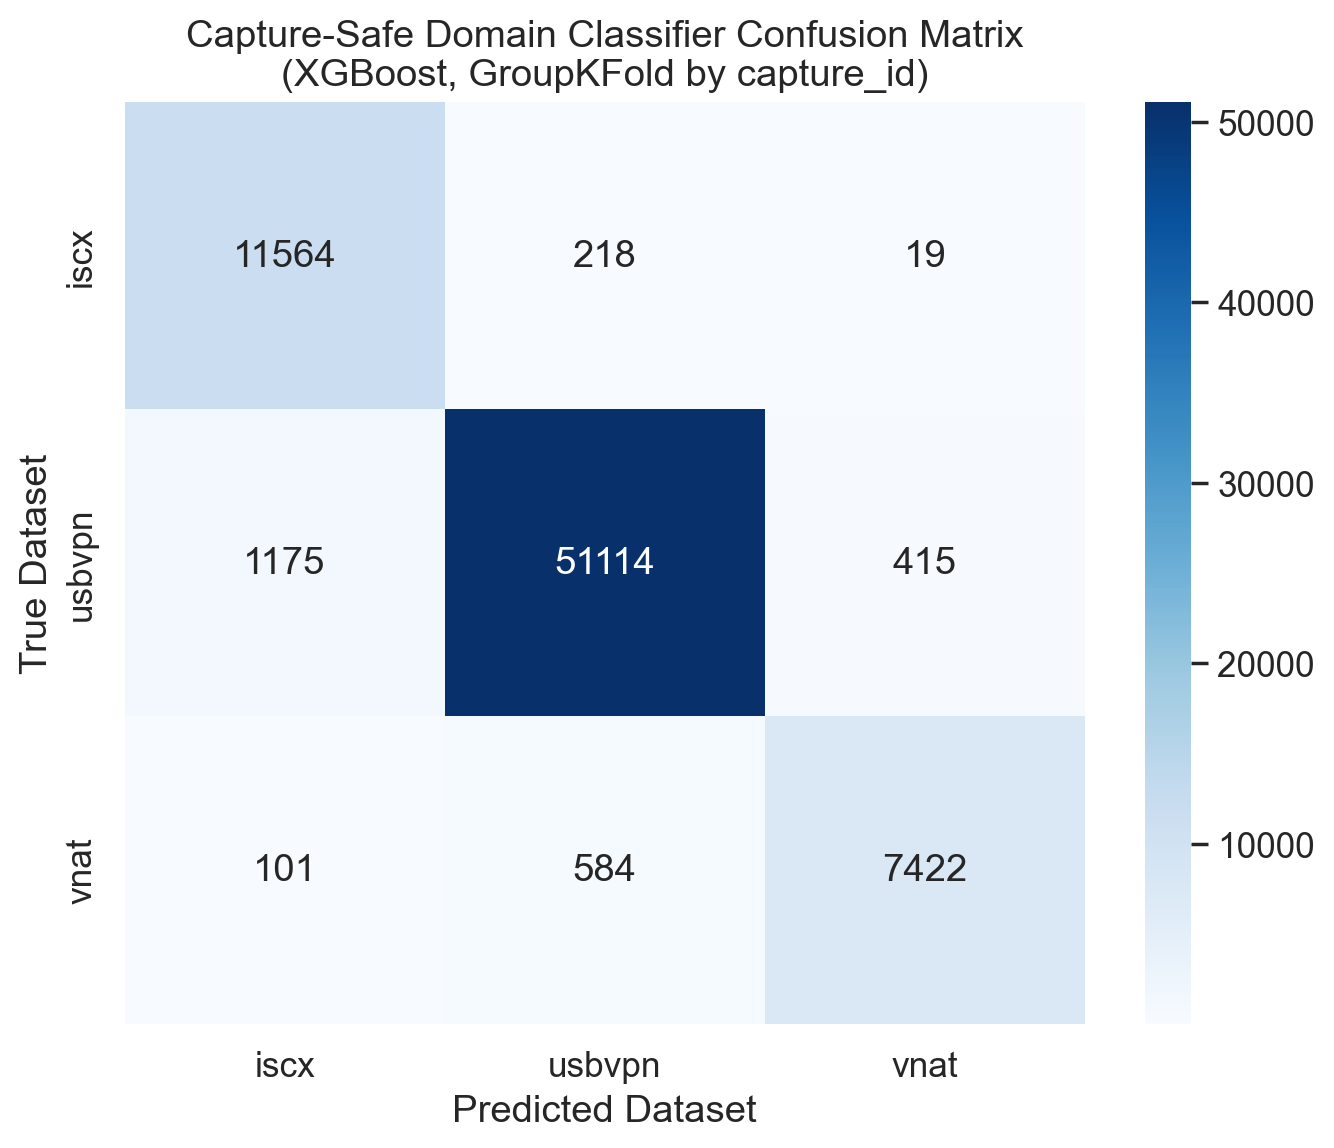


---
### 🖼 {_p.stem.replace("_", " ").title()}

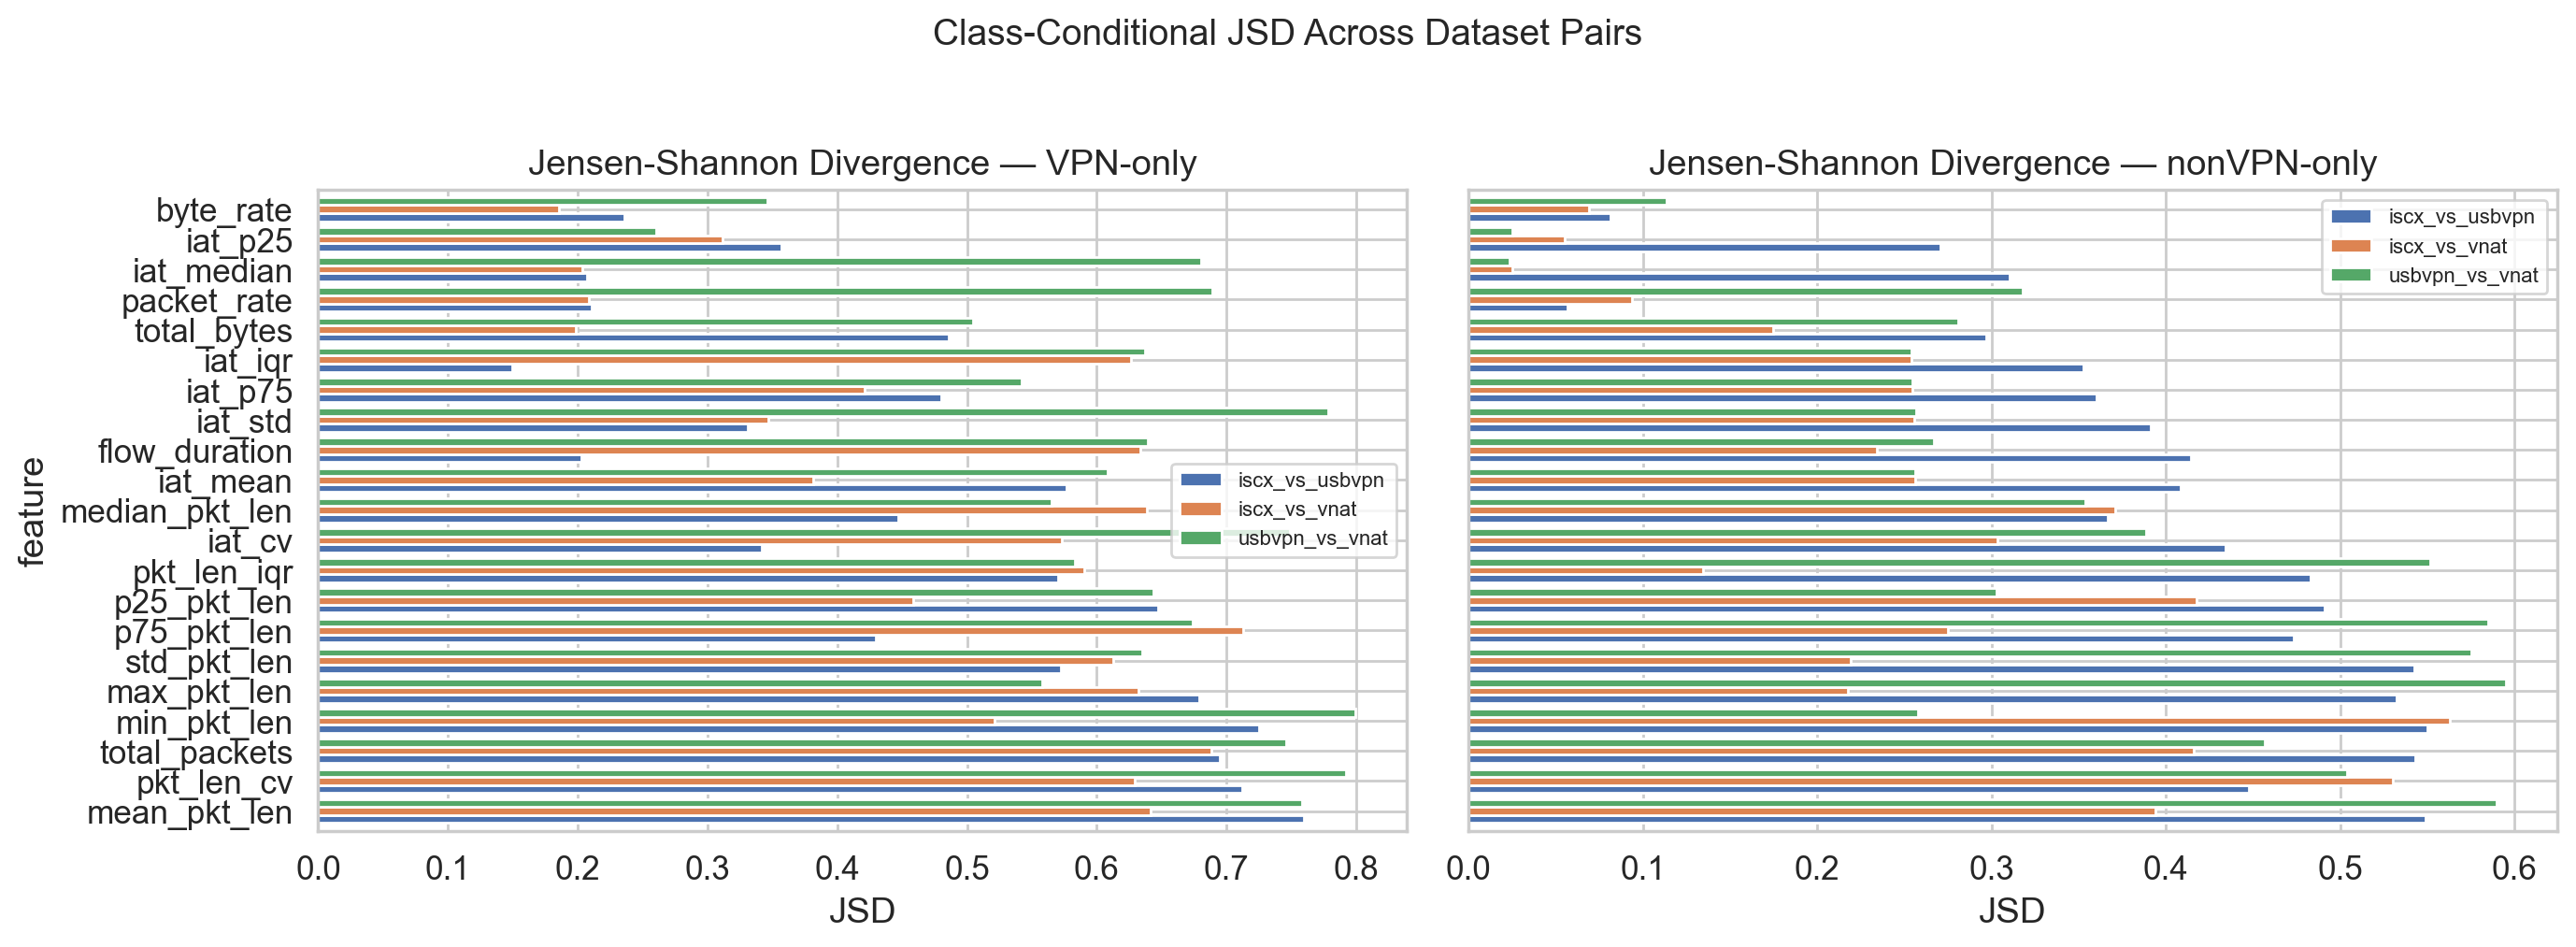


---
### 🖼 {_p.stem.replace("_", " ").title()}

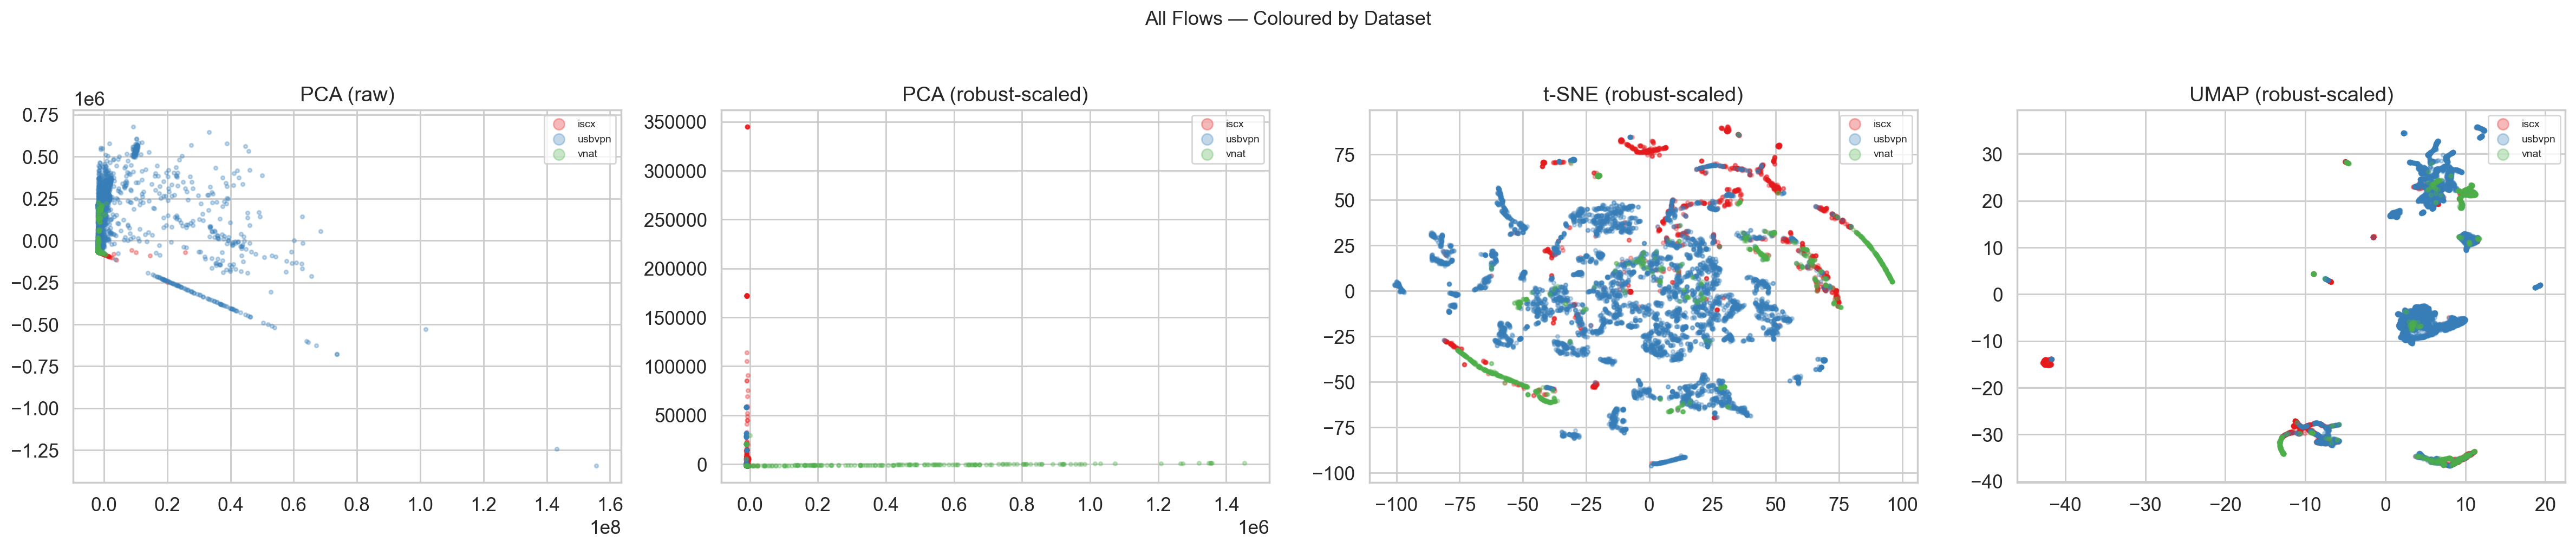


---
### 🖼 {_p.stem.replace("_", " ").title()}

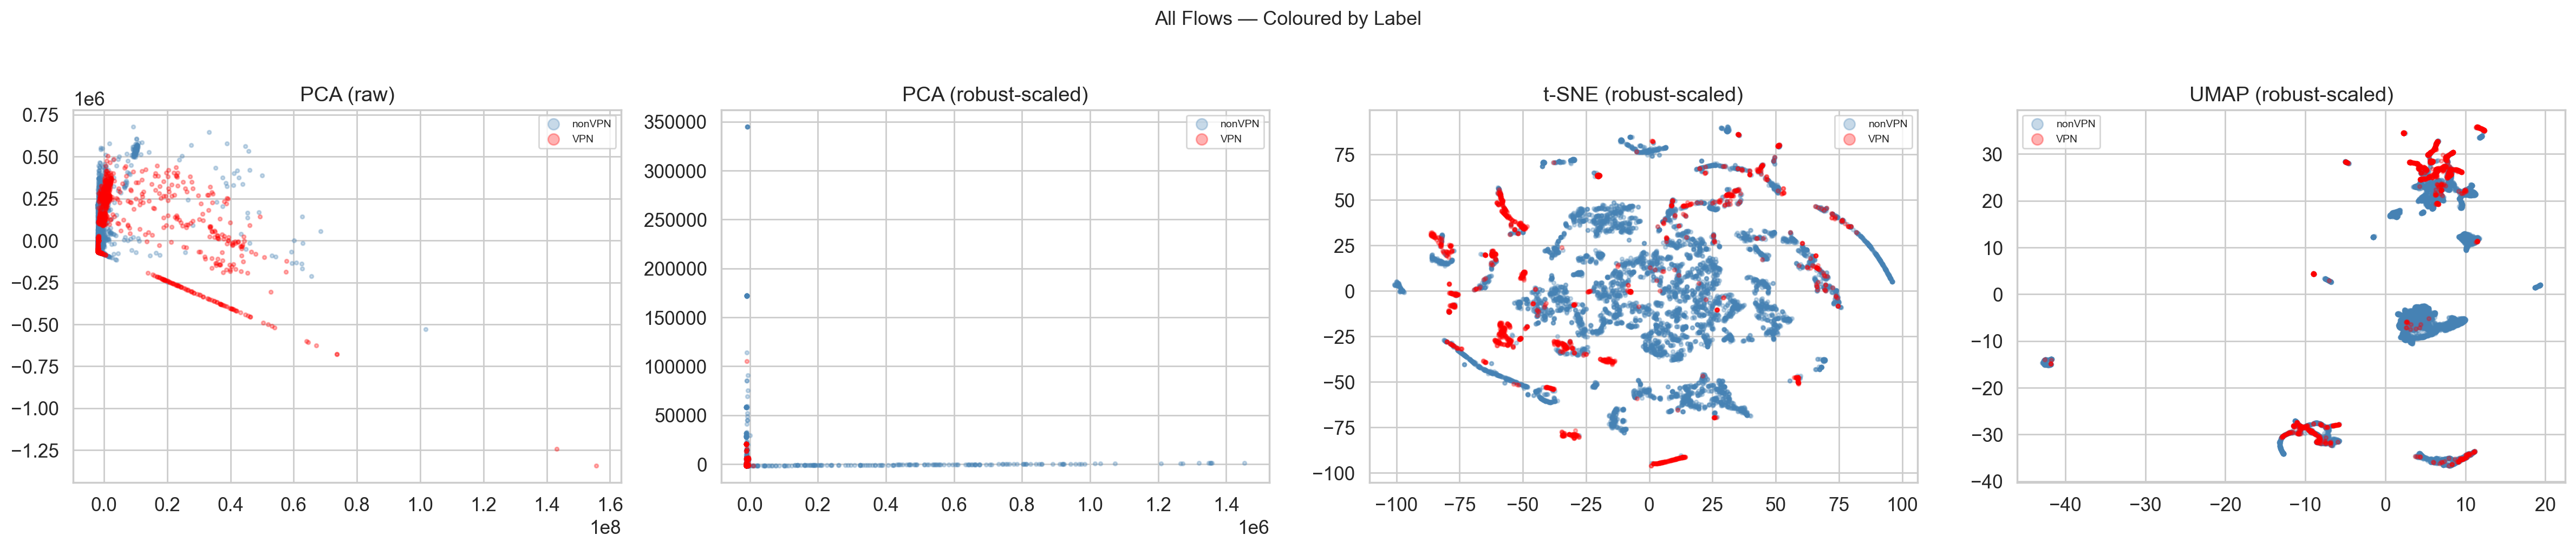


---
### 🖼 {_p.stem.replace("_", " ").title()}

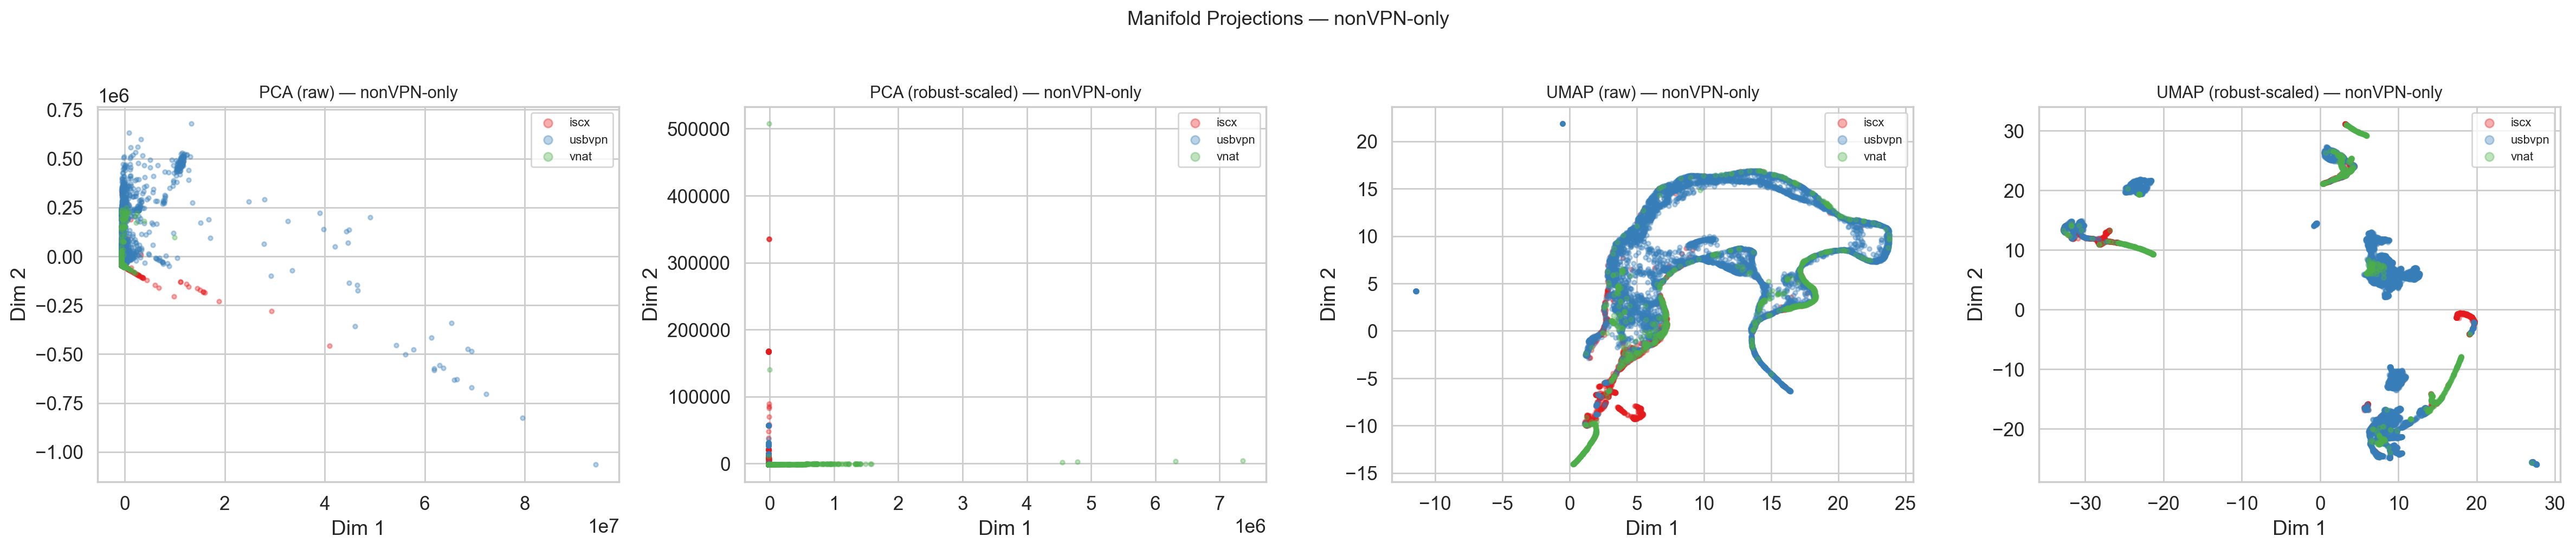


---
### 🖼 {_p.stem.replace("_", " ").title()}

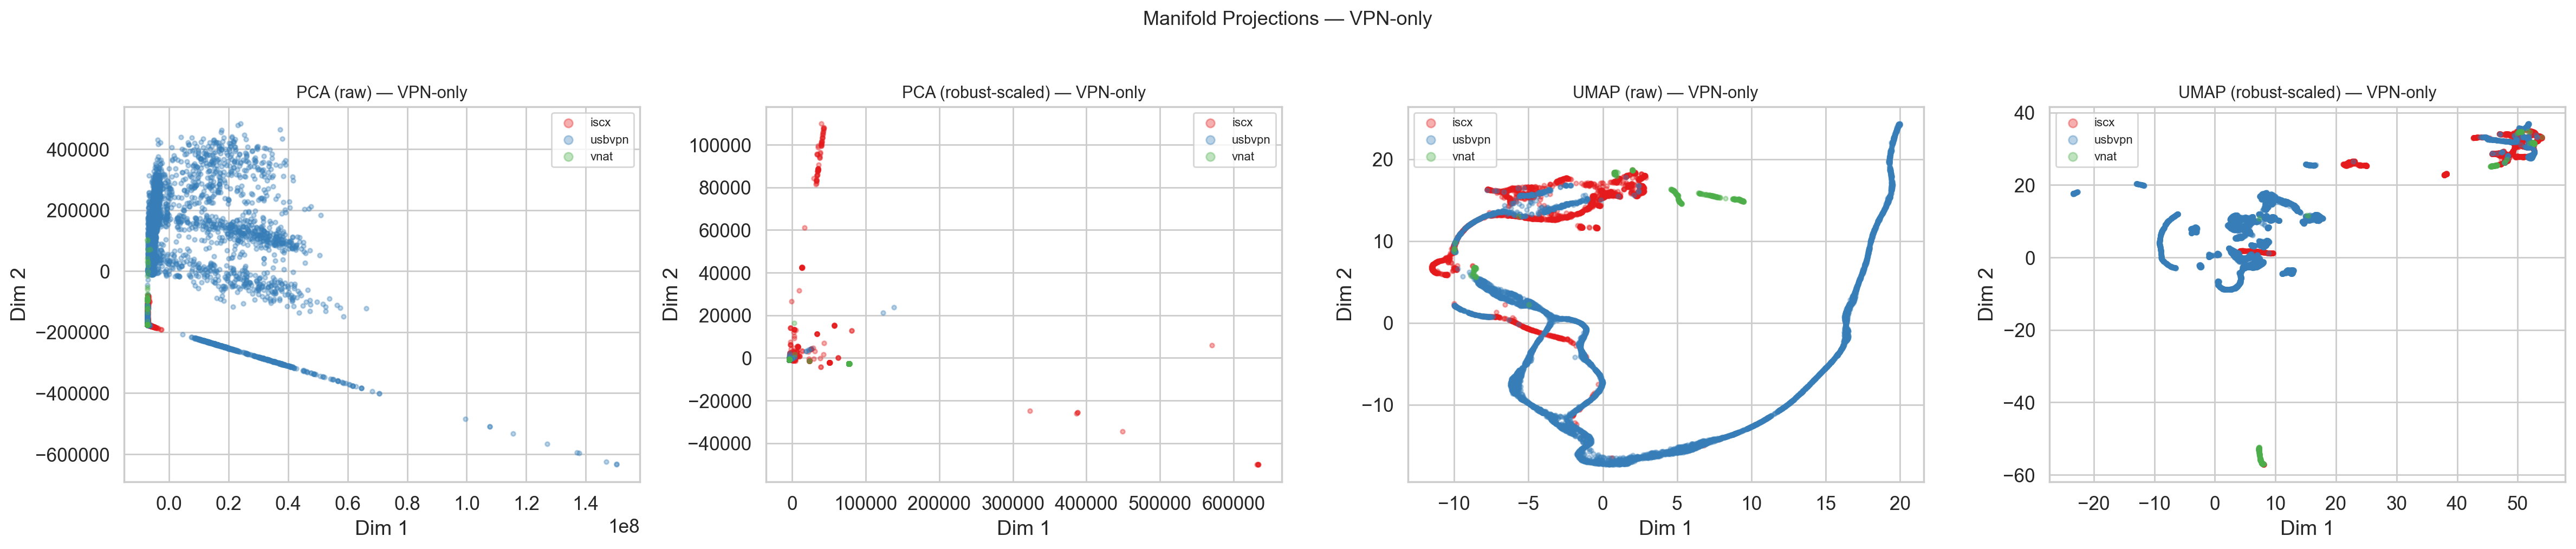


---
### 🖼 {_p.stem.replace("_", " ").title()}

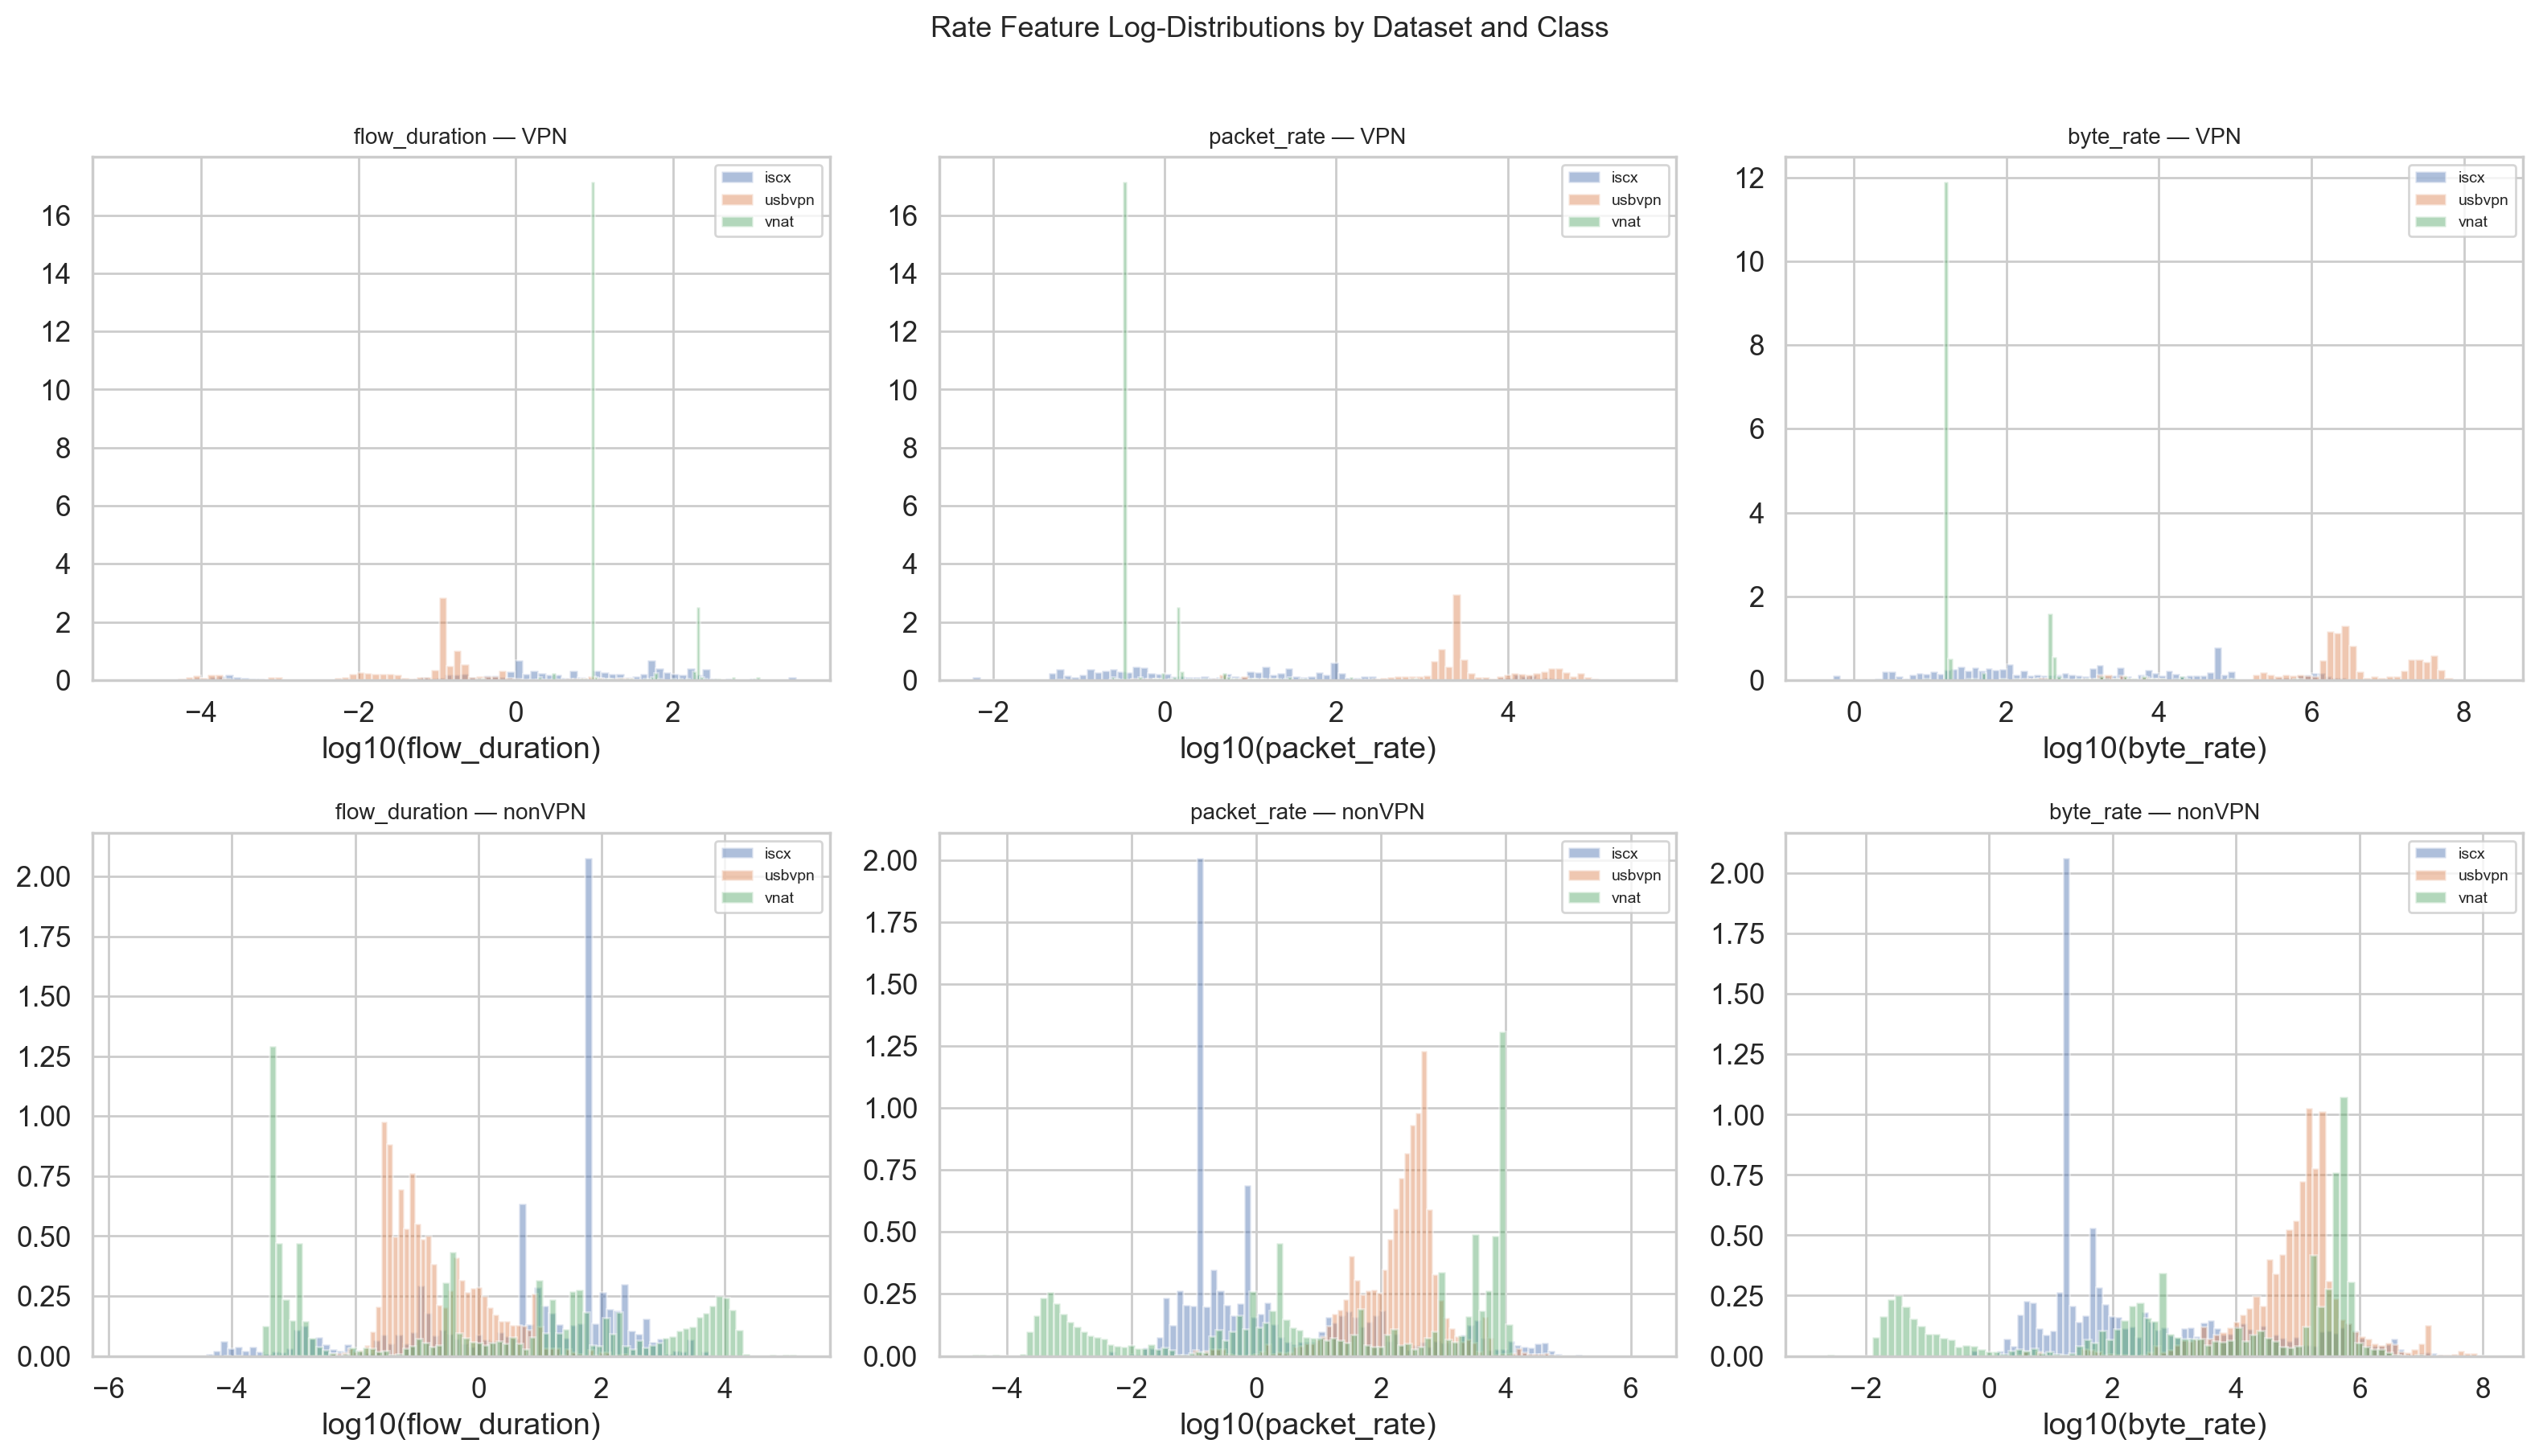


---
### 🖼 {_p.stem.replace("_", " ").title()}

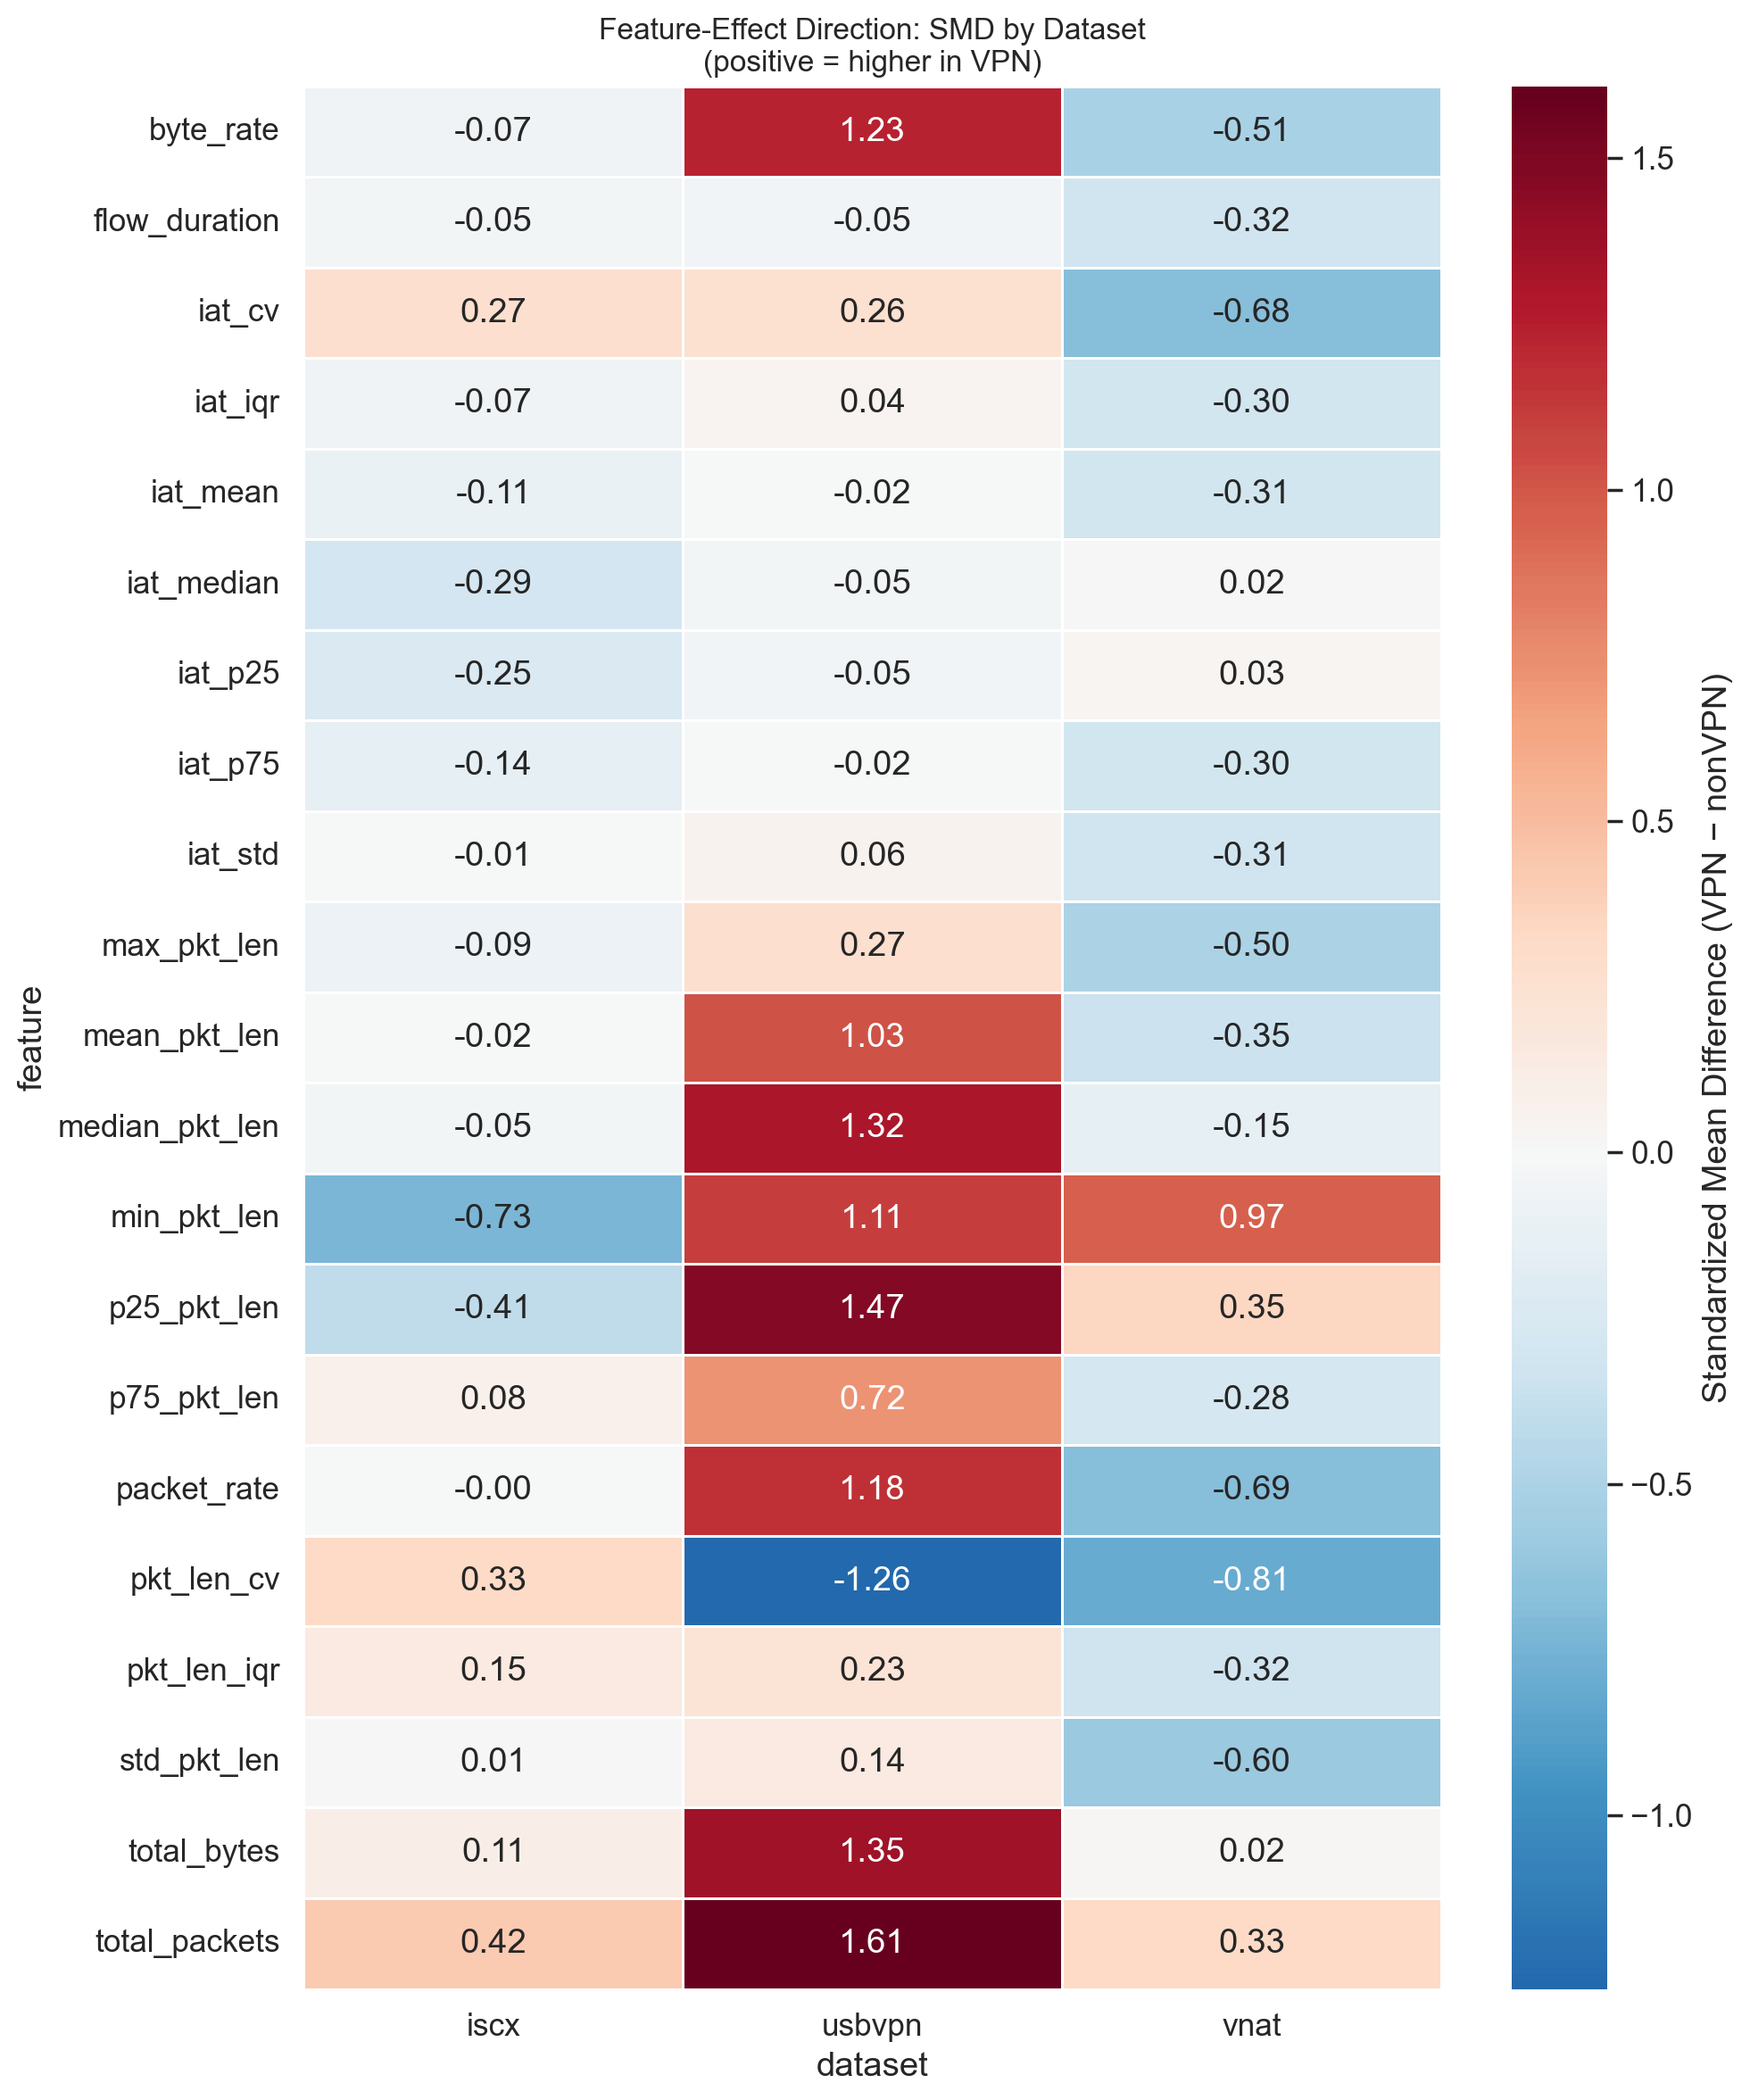


---
# 📋 Result Tables


### {_c.stem.replace("_", " ").title()}

,Unnamed: 0,subset,model,n_flows,n_captures,mean_macro_auc,std_macro_auc,mean_accuracy,mean_macro_f1
0,0,all,LogisticRegression,72612,340,0.8389,0.0327,0.5099,0.4080
1,1,all,XGBoost,72612,340,0.9981,0.0023,0.9684,0.8303
2,2,VPN-only,LogisticRegression,11773,143,0.9847,0.0096,0.9285,0.8599
3,3,VPN-only,XGBoost,11773,143,0.9998,0.0003,0.9911,0.9809
4,4,nonVPN-only,LogisticRegression,60839,197,0.8198,0.0567,0.4778,0.3636
5,5,nonVPN-only,XGBoost,60839,197,0.9985,0.0021,0.9791,0.7962


### {_c.stem.replace("_", " ").title()}

,Unnamed: 0,subset,pair,mean_abs_corr_diff,max_abs_corr_diff,n_pairs_gt_0.3,n_pairs_gt_0.5,total_pairs
0,0,VPN-only,iscx_vs_usbvpn,0.2925,0.9628,87,42,210
1,1,VPN-only,iscx_vs_vnat,0.4060,1.2218,130,65,210
2,2,VPN-only,usbvpn_vs_vnat,0.5898,1.6831,166,117,210
3,3,nonVPN-only,iscx_vs_usbvpn,0.3284,1.3105,90,48,210
4,4,nonVPN-only,iscx_vs_vnat,0.3304,0.8933,111,50,210
5,5,nonVPN-only,usbvpn_vs_vnat,0.4254,1.2652,134,79,210


...


---
### 🏁 {_j.stem.replace("_", " ").title()}

```json
{
  "notebook": "44_class_conditional_structural_audit_and_rate_sanity",
  "date": "2026-04-04",
  "relation_to_nb41": "Corrective and strengthening companion",
  "findings": {
    "class_conditional_shift": {
      "found": true,
      "vpn_domain_auc": 0.9998156909464546,
      "nonvpn_domain_auc": 0.9986231455332362,
      "both_severe": true,
      "summary": "BOTH \u2014 structural shift is severe in both VPN and benign traffic"
    },
    "rate_feature_problems": {
      "found": false,
      "verdict": "NEUTRAL \u2014 rate features do not materially affect transfer",
      "lodo_delta": 0.020433127930338302,
      "recomp_consistency": 0.9999999999999994
    },
    "sign_reversal": {
      "found": "True",
      "n_reversing_features": "16",
      "n_total_features": 21,
      "reversing_features": [
        "mean_pkt_len",
        "std_pkt_len",
        "median_pkt_len",
        "p25_pkt_len",
        "p75_pkt_len",
        "iat_std",
        "iat_median",
        "packet_rate",
        "byte_rate",
        "max_pkt_len",
        "min_pkt_len",
        "iat_cv",
        "iat_p25",
        "iat_iqr",
        "pkt_len_cv",
        "pkt_len_iqr"
      ]
    },
    "capture_safe_domain_fingerprinting": {
      "confirmed": "True",
      "capture_safe_auc": 0.9981234065011415,
      "verdict": "CONFIRMED \u2014 domain AUC remains near-perfect under capture-safe evaluation"
    },
    "plausible_remaining_bug": {
      "found": false,
      "explanation": "No implementation-level bug detected. All feature computations are consistent and verified."
    },
    "realistic_feature_fix": {
      "exists": false,
      "explanation": "No simple feature-level fix can resolve the structural mismatch. The problem is inherent to the diversity of capture environments and the header-only feature representation. Future work should explore domain-adversarial training, meta-learning, or richer feature sets."
    }
  },
  "strongest_explanation": "The cross-dataset transfer failure is caused by a combination of: (1) class-conditional structural mismatch in both VPN and benign traffic, (2) environment-specific statistical shortcuts learned by the model, and (3) feature-effect sign inversions across datasets. These factors make the feature space inherently domain-encoded, preventing generalization despite clean, leakage-free feature computation.",
  "what_this_changes_relative_to_nb41": [
    "Confirms and strengthens the structural shift finding with class-conditional evidence.",
    "Adds rate-feature sanity verification (or identifies instability).",
    "Identifies specific sign-reversing features as a key transfer failure mechanism.",
    "Validates domain classifier AUC under capture-safe evaluation.",
    "Provides corrected academic wording for thesis/paper use."
  ],
  "artifacts_generated": [
    "feature_family_consistency_table.csv",
    "vpn_only_distance_matrix.csv",
    "nonvpn_only_distance_matrix.csv",
    "vpn_only_domain_classifier_results.csv
```


---
### 🏁 {_j.stem.replace("_", " ").title()}

```json
{
  "rate_verdict": "NEUTRAL \u2014 rate features do not materially affect transfer",
  "lodo_full": 0.49639749149970397,
  "lodo_no_rate": 0.5168306194300423,
  "delta": 0.020433127930338302,
  "recomp_min_pearson": 0.9999999999999994
}
```


✅ NB44 gallery complete.


In [31]:
# ── Results Gallery: NB44 — Display all figures and tables ────────
import json, warnings
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

warnings.filterwarnings('ignore')

# Resolve output directory
if 'OUT' not in dir() and 'OUT_DIR' not in dir():
    ROOT = Path.cwd()
    if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
        ROOT = ROOT.parent
    _gallery_dir = ROOT / "artifacts" / "thesis_class_conditional_audit_notebook"
else:
    _gallery_dir = Path(str(OUT)) if 'OUT' in dir() else Path(str(OUT_DIR))

# Also check for a figures/ subdirectory
_fig_dir = _gallery_dir / 'figures'

# Collect all PNGs
_pngs = sorted(_gallery_dir.glob('*.png'))
if _fig_dir.exists():
    _pngs += sorted(_fig_dir.glob('*.png'))
_pngs = sorted(set(_pngs), key=lambda p: p.name)

# Collect all CSVs
_csvs = sorted(_gallery_dir.glob('*.csv'))

display(Markdown(f'# \U0001f4ca NB44 Results Gallery — {len(_pngs)} figures, {len(_csvs)} tables'))

# ── Display all PNG figures ──
if _pngs:
    for _p in _pngs:
        display(Markdown(f'\n---\n### \U0001f5bc {{_p.stem.replace("_", " ").title()}}'))
        try:
            display(Image(filename=str(_p), width=900))
        except Exception as _e:
            display(Markdown(f'*Could not display {_p.name}: {_e}*'))
else:
    display(Markdown('*No PNG files found in gallery directory. Run notebook cells first.*'))

# ── Display all CSV tables ──
if _csvs:
    display(Markdown('\n---\n# \U0001f4cb Result Tables\n'))
    for _c in _csvs:
        try:
            _tbl = pd.read_csv(_c)
            display(Markdown(f'### {{_c.stem.replace("_", " ").title()}}'))
            for _col in _tbl.select_dtypes(include="float").columns:
                _tbl[_col] = _tbl[_col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
            display(_tbl)
        except Exception as _e:
            display(Markdown(f'*Could not load {_c.name}: {_e}*'))

# ── Display JSON verdict if present ──
_jsons = sorted(_gallery_dir.glob('*verdict*.json')) + sorted(_gallery_dir.glob('*summary*.json'))
_jsons = sorted(set(_jsons), key=lambda p: p.name)
for _j in _jsons[:2]:
    try:
        _data = json.loads(_j.read_text(encoding='utf-8'))
        display(Markdown(f'\n---\n### \U0001f3c1 {{_j.stem.replace("_", " ").title()}}'))
        display(Markdown(f'```json\n{json.dumps(_data, indent=2, default=str)[:3000]}\n```'))
    except Exception:
        pass

print('\n\u2705 NB44 gallery complete.')
